# Formale Utility-Evaluation fuer H/k-Kombinationen

Dieses Notebook ist ein separates Formel-Labor. Es laedt nur die globale Experimentzusammenfassung, aggregiert sie nach H/k und vergleicht mehrere Utility-Funktionen auf derselben Datenbasis.

Untersucht werden:

1. Additive Penalty-Utility als aktuelle Referenz.
2. Success-dominante Wechselwirkungs-Utility.
3. Normalisierte verschobene quadratische Erfolgsfunktion mit mehreren $x$-Werten.
4. Cobb-Douglas-Utility mit mehreren $\varepsilon$-Werten.
5. Logistische additive und multiplikative Utility.

Alle Tabellen und Rangfolgen sind global; Site-spezifische Auswertungen bleiben bewusst ausserhalb dieses Notebooks.


In [81]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

ROOT = Path.cwd()
if not (ROOT / "runs").exists():
    ROOT = ROOT.parent

EXPERIMENT_NAME = "hk-agent-browsergym-planact-main-v02_basis_v3"
SUMMARY_CSV = ROOT / "runs" / "hk-agent" / EXPERIMENT_NAME / "summary.csv"

if not SUMMARY_CSV.exists():
    raise FileNotFoundError(f"summary.csv nicht gefunden: {SUMMARY_CSV}")

PERSONAS = {
    "main_accuracy_first": {"alpha": 0.90, "beta": 0.05, "gamma": 0.05},
    "cost_sensitive": {"alpha": 0.80, "beta": 0.15, "gamma": 0.05},
    "time_sensitive": {"alpha": 0.80, "beta": 0.05, "gamma": 0.15},
    "stress_80": {"alpha": 0.75, "beta": 0.125, "gamma": 0.125},
}

for name, weights in PERSONAS.items():
    if not np.isclose(sum(weights.values()), 1.0):
        raise ValueError(f"{name}: alpha + beta + gamma muss 1 ergeben.")
    if weights["alpha"] < 0.75 or weights["beta"] + weights["gamma"] > 0.25 + 1e-9:
        raise ValueError(f"{name}: Nebenbedingungen verletzt.")

print(f"Datenquelle: {SUMMARY_CSV}")


Datenquelle: /Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-agent/hk-agent-browsergym-planact-main-v02_basis_v3/summary.csv


## 1. Datenbasis und gemeinsame Normalisierung

Alle Formeln erhalten dieselben Eingaben:

* $S$: offizielle globale Success Rate.
* $T_{norm}$: Min-Max-normalisierter mittlerer Tokenverbrauch.
* $\tau_{norm}$: Min-Max-normalisierte mittlere Laufzeit.

Damit lassen sich Rangwechsel auf die Form der Utility zurückführen und nicht auf unterschiedliche Vorverarbeitung.


In [82]:
def as_bool(series):
    if series.dtype == bool:
        return series.astype(int)
    return (
        series.astype(str).str.strip().str.lower()
        .isin({"1", "true", "yes", "y", "success"})
        .astype(int)
    )


def minmax_norm(series):
    values = pd.to_numeric(series, errors="coerce").astype(float)
    lo, hi = values.min(), values.max()
    if not np.isfinite(lo) or not np.isfinite(hi) or np.isclose(lo, hi):
        return pd.Series(0.0, index=series.index)
    return (values - lo) / (hi - lo)


def build_hk_table(summary_csv):
    runs = pd.read_csv(summary_csv).copy()
    if "official_success_bool" in runs.columns:
        runs["success"] = as_bool(runs["official_success_bool"])
    elif "official_success" in runs.columns:
        runs["success"] = as_bool(runs["official_success"])
    elif "official_score" in runs.columns:
        runs["success"] = pd.to_numeric(runs["official_score"], errors="coerce").fillna(0).gt(0).astype(int)
    else:
        raise KeyError("Keine offizielle Success-Spalte gefunden.")

    if "total_tokens" in runs.columns:
        runs["tokens"] = pd.to_numeric(runs["total_tokens"], errors="coerce").fillna(0.0)
    elif "tokens" not in runs.columns:
        raise KeyError("Keine Token-Spalte gefunden.")
    else:
        runs["tokens"] = pd.to_numeric(runs["tokens"], errors="coerce").fillna(0.0)

    if "total_runtime_ms" in runs.columns:
        runs["runtime_s"] = pd.to_numeric(runs["total_runtime_ms"], errors="coerce") / 1000.0
    elif "runtime_s" in runs.columns:
        runs["runtime_s"] = pd.to_numeric(runs["runtime_s"], errors="coerce")
    else:
        runs["runtime_s"] = np.nan

    required = {"h", "k"}
    missing = required.difference(runs.columns)
    if missing:
        raise KeyError(f"Fehlende H/k-Spalten: {sorted(missing)}")

    hk = (
        runs.groupby(["h", "k"], dropna=False)
        .agg(
            runs=("success", "size"),
            tasks=("task_id", "nunique") if "task_id" in runs.columns else ("success", "size"),
            successes=("success", "sum"),
            success_rate=("success", "mean"),
            avg_tokens=("tokens", "mean"),
            avg_runtime_s=("runtime_s", "mean"),
        )
        .reset_index()
        .sort_values(["h", "k"])
        .reset_index(drop=True)
    )
    hk["hk"] = "h" + hk["h"].astype(int).astype(str) + "/k" + hk["k"].astype(int).astype(str)
    hk["success_rate_pct"] = hk["success_rate"] * 100
    hk["avg_tokens_k"] = hk["avg_tokens"] / 1000.0
    hk["T_norm"] = minmax_norm(hk["avg_tokens"])
    hk["runtime_norm"] = minmax_norm(hk["avg_runtime_s"])
    return runs, hk


runs_df, hk_df = build_hk_table(SUMMARY_CSV)
display(Markdown(f"**Runs:** {len(runs_df)} | **H/k-Kombinationen:** {len(hk_df)}"))
display(hk_df[["hk", "runs", "tasks", "success_rate_pct", "avg_tokens_k", "avg_runtime_s", "T_norm", "runtime_norm"]].style.format({
    "success_rate_pct": "{:.1f}%", "avg_tokens_k": "{:.1f}k", "avg_runtime_s": "{:.1f}s", "T_norm": "{:.3f}", "runtime_norm": "{:.3f}",
}))


**Runs:** 3360 | **H/k-Kombinationen:** 16

,hk,runs,tasks,success_rate_pct,avg_tokens_k,avg_runtime_s,T_norm,runtime_norm
0,h0/k0,210,210,4.3%,113.1k,60.2s,0.000,0.000
1,h0/k2,210,210,23.8%,675.7k,291.4s,0.718,0.795
2,h0/k5,210,210,29.0%,774.7k,279.7s,0.844,0.754
3,h0/k10,210,210,25.2%,812.3k,290.0s,0.892,0.790
4,h2/k0,210,210,21.0%,762.6k,287.3s,0.828,0.781
5,h2/k2,210,210,28.1%,897.0k,351.1s,1.000,1.000
6,h2/k5,210,210,28.6%,883.1k,304.7s,0.982,0.840
7,h2/k10,210,210,27.6%,884.5k,306.8s,0.984,0.848
8,h5/k0,210,210,9.5%,215.4k,85.2s,0.130,0.086
9,h5/k2,210,210,26.7%,814.0k,304.4s,0.894,0.839


## 2. Utility-Funktionen

Die Funktionen werden bewusst separat definiert. So kann jede Annahme einzeln geprüft werden.

* **Additive Penalty:** $\alpha S-\beta T_{norm}-\gamma\tau_{norm}$.
* **Wechselwirkung:** $S[\alpha+\beta(1-T_{norm})+\gamma(1-\tau_{norm})]$.
* **Quadratisch:** $\alpha g_x(S)-\beta T_{norm}-\gamma\tau_{norm}$ mit $g_x(S)=\frac{S^2+2xS}{1+2x}$.
* **Cobb-Douglas:** $S^\alpha(\varepsilon+1-T_{norm})^\beta(\varepsilon+1-\tau_{norm})^\gamma$.

### Logistische Einzelutilities

Für alle drei Dimensionen wird ein logistischer Nutzen auf dem Intervall $[0,1]$ gebildet. Dabei steht $x$ jeweils für die passende Eingangsdimension: $S$ für Erfolg, $T_{norm}$ für Kosten bzw. Tokenverbrauch und $\tau_{norm}$ für Aufwand bzw. Laufzeit.

$$
U_{Erfolg}(S)=\frac{1}{1+\exp\left[-k_1(S-x_{01})\right]}
$$

$$
U_{Kosten}(T)=\frac{1}{1+\exp\left[k_2(T_{norm}-x_{02})\right]}
$$

$$
U_{Aufwand}(\tau)=\frac{1}{1+\exp\left[k_3(\tau_{norm}-x_{03})\right]}
$$

Das positive Vorzeichen vor $k_2$ und $k_3$ macht Kosten- und Aufwandnutzen fallend: Hohe normalisierte Tokenkosten oder Laufzeiten senken den jeweiligen Nutzen. $x_{01}$, $x_{02}$ und $x_{03}$ sind Wendepunkte; $k_1$, $k_2$, $k_3$ steuern jeweils die Steilheit und damit den Wert kleiner Veränderungen in der Nähe des Wendepunkts.

Die Einzelutilities werden in zwei Varianten verknüpft:

$$
U_{logistisch,additiv}=\alpha U_{Erfolg}+\beta U_{Kosten}+\gamma U_{Aufwand}
$$

$$
U_{logistisch,multiplikativ}=U_{Erfolg}\cdot U_{Kosten}\cdot U_{Aufwand}
$$

Die additive Variante ist persona-fähig, kann aber kompensieren. Die multiplikative Variante ist absichtlich nicht kompensatorisch: Nähert sich eine Komponente wegen sehr hoher Kosten oder Laufzeit null, fällt auch die Gesamtutility gegen null.


In [83]:
def utility_additive_penalty(frame, alpha, beta, gamma):
    return alpha * frame["success_rate"] - beta * frame["T_norm"] - gamma * frame["runtime_norm"]


def utility_success_interaction(frame, alpha, beta, gamma):
    return frame["success_rate"] * (
        alpha + beta * (1 - frame["T_norm"]) + gamma * (1 - frame["runtime_norm"])
    )


def shifted_quadratic_success(success_rate, x):
    # g_x(0)=0 und g_x(1)=1; x steuert die Empfindlichkeit bei kleinen Success Rates.
    return (success_rate**2 + 2 * x * success_rate) / (1 + 2 * x)


def utility_shifted_quadratic(frame, alpha, beta, gamma, x):
    return alpha * shifted_quadratic_success(frame["success_rate"], x) - beta * frame["T_norm"] - gamma * frame["runtime_norm"]


def utility_cobb_douglas(frame, alpha, beta_runtime, gamma_token, epsilon=0.01):
    """Cobb-Douglas nach U=A*S^alpha*(1-runtime)^beta*(1-token)^gamma.

    beta_runtime und gamma_token sind absichtlich so benannt, weil die bisherige
    Persona-Definition beta=Token und gamma=Laufzeit verwendet.
    """
    success = frame["success_rate"].clip(lower=0)
    runtime_efficiency = (epsilon + 1 - frame["runtime_norm"]).clip(lower=epsilon)
    token_efficiency = (epsilon + 1 - frame["T_norm"]).clip(lower=epsilon)
    return success**alpha * runtime_efficiency**beta_runtime * token_efficiency**gamma_token


def _sigmoid(value):
    # Clip verhindert numerische Ueberlaeufe bei sehr hohen Steilheiten.
    return 1 / (1 + np.exp(-np.clip(value, -700, 700)))


def utility_success_logistic(success_rate, x01, k1):
    return _sigmoid(k1 * (success_rate - x01))


def utility_cost_logistic(token_norm, x02, k2):
    # Positives k2 im Exponenten: steigende Kosten senken den Nutzen.
    return _sigmoid(-k2 * (token_norm - x02))


def utility_effort_logistic(runtime_norm, x03, k3):
    # Positives k3 im Exponenten: steigender Aufwand senkt den Nutzen.
    return _sigmoid(-k3 * (runtime_norm - x03))


def logistic_components(frame, x01=0.25, x02=0.50, x03=0.50, k1=10.0, k2=10.0, k3=10.0):
    return pd.DataFrame({
        "U_erfolg": utility_success_logistic(frame["success_rate"], x01=x01, k1=k1),
        "U_kosten": utility_cost_logistic(frame["T_norm"], x02=x02, k2=k2),
        "U_aufwand": utility_effort_logistic(frame["runtime_norm"], x03=x03, k3=k3),
    }, index=frame.index)


def utility_logistic_additive(frame, alpha, beta, gamma, **params):
    components = logistic_components(frame, **params)
    return alpha * components["U_erfolg"] + beta * components["U_kosten"] + gamma * components["U_aufwand"]


def utility_logistic_multiplicative(frame, alpha, beta, gamma, **params):
    # Reines Produkt wie in der formalen Definition; alpha/beta/gamma werden bewusst nicht verwendet.
    del alpha, beta, gamma
    components = logistic_components(frame, **params)
    return components["U_erfolg"] * components["U_kosten"] * components["U_aufwand"]


## 3. Formelraum berechnen

Die Personenprofile bleiben für alle Familien gleich. Bei Cobb-Douglas und logistischer Multiplikation sind $\alpha$, $\beta$, $\gamma$ Exponenten, nicht direkte lineare Prozentgewichte.


In [84]:
QUADRATIC_X_VALUES = [0.00, 0.05, 0.10, 0.20]
COBB_EPSILON_VALUES = [0.001, 0.01, 0.05]
LOGISTIC_DEFAULT = {
    "x01": 0.25,  # Success-Wendepunkt: ab 25% nimmt Erfolgsnutzen stark zu.
    "x02": 0.50,  # Kosten-Wendepunkt: ab mittlerem Tokenverbrauch sinkt Kostennutzen stark.
    "x03": 0.50,  # Aufwands-Wendepunkt: ab mittlerer Laufzeit sinkt Aufwandsnutzen stark.
    "k1": 10.0,
    "k2": 10.0,
    "k3": 10.0,
}


def collect_utilities(hk_table):
    rows = []
    for persona, weights in PERSONAS.items():
        formulae = {
            "additive_penalty": utility_additive_penalty(hk_table, **weights),
            "success_interaction": utility_success_interaction(hk_table, **weights),
            "logistic_additive": utility_logistic_additive(hk_table, **weights, **LOGISTIC_DEFAULT),
            "logistic_multiplicative": utility_logistic_multiplicative(hk_table, **weights, **LOGISTIC_DEFAULT),
        }
        for x in QUADRATIC_X_VALUES:
            formulae[f"shifted_quadratic_x={x:.2f}"] = utility_shifted_quadratic(hk_table, **weights, x=x)
        for epsilon in COBB_EPSILON_VALUES:
            formulae[f"cobb_douglas_eps={epsilon:.3f}"] = utility_cobb_douglas(
                hk_table,
                alpha=weights["alpha"],
                beta_runtime=weights["gamma"],
                gamma_token=weights["beta"],
                epsilon=epsilon,
            )

        for formula, values in formulae.items():
            part = hk_table[["hk", "h", "k", "success_rate_pct", "avg_tokens_k", "avg_runtime_s", "T_norm", "runtime_norm"]].copy()
            part["persona"] = persona
            part["formula"] = formula
            part["utility"] = np.asarray(values, dtype=float)
            part["rank"] = part["utility"].rank(method="min", ascending=False).astype(int)
            rows.append(part)
    return pd.concat(rows, ignore_index=True)


utility_long = collect_utilities(hk_df)
display(Markdown(f"**Berechnete Fälle:** {len(utility_long):,} (H/k × Personas × Formelvarianten)"))
utility_long.head()


**Berechnete Fälle:** 704 (H/k × Personas × Formelvarianten)

,hk,h,k,success_rate_pct,avg_tokens_k,avg_runtime_s,T_norm,runtime_norm,persona,formula,utility,rank
0,h0/k0,0,0,4.285714,113.106529,60.247648,0.000000,0.000000,main_accuracy_first,additive_penalty,0.038571,16
1,h0/k2,0,2,23.809524,675.730195,291.428081,0.717711,0.794806,main_accuracy_first,additive_penalty,0.138660,11
2,h0/k5,0,5,29.047619,774.737605,279.663910,0.844010,0.754361,main_accuracy_first,additive_penalty,0.181510,2
3,h0/k10,0,10,25.238095,812.293395,289.968948,0.891918,0.789790,main_accuracy_first,additive_penalty,0.143057,8
4,h2/k0,2,0,20.952381,762.556424,287.319005,0.828471,0.780679,main_accuracy_first,additive_penalty,0.108114,13


## 4. Referenz: Rangfolge der aktuellen Penalty-Utility

Diese Tabelle ist die direkte Referenz zur großen Analyse. Alle nachfolgenden Rangwechsel werden gegen diese Formel verglichen.


In [85]:
baseline = utility_long.query("formula == 'additive_penalty'").copy()
for persona in PERSONAS:
    display(Markdown(f"### {persona}: additive Penalty-Referenz"))
    shown = baseline[baseline["persona"].eq(persona)].sort_values("rank")
    display(shown[["rank", "hk", "success_rate_pct", "avg_tokens_k", "avg_runtime_s", "utility"]].head(10).style.format({
        "success_rate_pct": "{:.1f}%", "avg_tokens_k": "{:.1f}k", "avg_runtime_s": "{:.1f}s", "utility": "{:.4f}",
    }))


### main_accuracy_first: additive Penalty-Referenz

,rank,hk,success_rate_pct,avg_tokens_k,avg_runtime_s,utility
10,1,h5/k5,31.4%,876.8k,317.8s,0.1899
2,2,h0/k5,29.0%,774.7k,279.7s,0.1815
15,3,h10/k10,29.0%,823.9k,298.0s,0.1752
6,4,h2/k5,28.6%,883.1k,304.7s,0.1660
7,5,h2/k10,27.6%,884.5k,306.8s,0.1570
9,6,h5/k2,26.7%,814.0k,304.4s,0.1533
5,7,h2/k2,28.1%,897.0k,351.1s,0.1529
3,8,h0/k10,25.2%,812.3k,290.0s,0.1431
14,9,h10/k5,25.2%,811.8k,292.2s,0.1427
13,10,h10/k2,23.8%,705.5k,268.5s,0.1407


### cost_sensitive: additive Penalty-Referenz

,rank,hk,success_rate_pct,avg_tokens_k,avg_runtime_s,utility
188,1,h10/k0,9.0%,120.8k,63.2s,0.0704
178,2,h0/k5,29.0%,774.7k,279.7s,0.0681
186,3,h5/k5,31.4%,876.8k,317.8s,0.0610
191,4,h10/k10,29.0%,823.9k,298.0s,0.0555
184,5,h5/k0,9.5%,215.4k,85.2s,0.0523
177,6,h0/k2,23.8%,675.7k,291.4s,0.0431
189,7,h10/k2,23.8%,705.5k,268.5s,0.0413
182,8,h2/k5,28.6%,883.1k,304.7s,0.0392
185,9,h5/k2,26.7%,814.0k,304.4s,0.0373
176,10,h0/k0,4.3%,113.1k,60.2s,0.0343


### time_sensitive: additive Penalty-Referenz

,rank,hk,success_rate_pct,avg_tokens_k,avg_runtime_s,utility
354,1,h0/k5,29.0%,774.7k,279.7s,0.0770
364,2,h10/k0,9.0%,120.8k,63.2s,0.0704
362,3,h5/k5,31.4%,876.8k,317.8s,0.0699
367,4,h10/k10,29.0%,823.9k,298.0s,0.0644
360,5,h5/k0,9.5%,215.4k,85.2s,0.0568
358,6,h2/k5,28.6%,883.1k,304.7s,0.0534
365,7,h10/k2,23.8%,705.5k,268.5s,0.0453
359,8,h2/k10,27.6%,884.5k,306.8s,0.0446
361,9,h5/k2,26.7%,814.0k,304.4s,0.0427
355,10,h0/k10,25.2%,812.3k,290.0s,0.0388


### stress_80: additive Penalty-Referenz

,rank,hk,success_rate_pct,avg_tokens_k,avg_runtime_s,utility
540,1,h10/k0,9.0%,120.8k,63.2s,0.0654
536,2,h5/k0,9.5%,215.4k,85.2s,0.0444
528,3,h0/k0,4.3%,113.1k,60.2s,0.0321
530,4,h0/k5,29.0%,774.7k,279.7s,0.0181
538,5,h5/k5,31.4%,876.8k,317.8s,0.0032
543,6,h10/k10,29.0%,823.9k,298.0s,0.0024
541,7,h10/k2,23.8%,705.5k,268.5s,-0.0054
529,8,h0/k2,23.8%,675.7k,291.4s,-0.0105
534,9,h2/k5,28.6%,883.1k,304.7s,-0.0135
537,10,h5/k2,26.7%,814.0k,304.4s,-0.0167


## 5. Rangwechsel zwischen den Utility-Funktionen

Die Matrix zeigt pro Persona den Rang jeder H/k-Kombination. Kleine Rangwerte sind besser. Dadurch wird sichtbar, ob eine andere Formulierung tatsächlich andere H/k-Kombinationen bevorzugt.


In [86]:
def rank_comparison_table(long_df, persona):
    subset = long_df[long_df["persona"].eq(persona)].copy()
    ranks = subset.pivot(index="hk", columns="formula", values="rank")
    utility = subset.pivot(index="hk", columns="formula", values="utility")
    ranks["rank_range"] = ranks.max(axis=1) - ranks.min(axis=1)
    ranks["best_rank"] = ranks.drop(columns="rank_range").min(axis=1)
    ranks["worst_rank"] = ranks.drop(columns=["rank_range", "best_rank"]).max(axis=1)
    ranks = ranks.sort_values(["rank_range", "best_rank"], ascending=[False, True])
    return ranks, utility

for persona in PERSONAS:
    ranks, _ = rank_comparison_table(utility_long, persona)
    display(Markdown(f"### {persona}: groesste Rangverschiebungen"))
    display(ranks.head(10).style.format("{:.0f}").background_gradient(cmap="YlGn_r", axis=0))


### main_accuracy_first: groesste Rangverschiebungen

formula,additive_penalty,cobb_douglas_eps=0.001,cobb_douglas_eps=0.010,cobb_douglas_eps=0.050,logistic_additive,logistic_multiplicative,shifted_quadratic_x=0.00,shifted_quadratic_x=0.05,shifted_quadratic_x=0.10,shifted_quadratic_x=0.20,success_interaction,rank_range,best_rank,worst_rank
hk,,,,,,,,,,,,,,
h10/k0,14,15,15,15,15,2,1,2,4,7,15,14,1,15
h5/k0,15,14,14,14,14,1,3,6,6,13,14,14,1,15
h0/k0,16,16,16,16,16,3,2,5,7,14,16,14,2,16
h5/k5,1,3,3,2,1,14,5,1,1,1,1,13,1,14
h2/k2,7,13,13,11,5,16,14,14,13,9,5,11,5,16
h2/k0,13,11,12,13,13,7,16,16,16,16,13,9,7,16
h10/k10,3,2,2,3,3,10,6,4,3,3,3,8,2,10
h2/k5,4,5,5,4,4,12,7,7,5,4,4,8,4,12
h2/k10,5,10,10,6,6,13,10,8,8,5,6,8,5,13


### cost_sensitive: groesste Rangverschiebungen

formula,additive_penalty,cobb_douglas_eps=0.001,cobb_douglas_eps=0.010,cobb_douglas_eps=0.050,logistic_additive,logistic_multiplicative,shifted_quadratic_x=0.00,shifted_quadratic_x=0.05,shifted_quadratic_x=0.10,shifted_quadratic_x=0.20,success_interaction,rank_range,best_rank,worst_rank
hk,,,,,,,,,,,,,,
h10/k0,1,14,14,15,14,2,1,1,1,1,15,14,1,15
h0/k0,10,16,16,16,16,3,2,2,2,2,16,14,2,16
h5/k0,5,13,13,14,13,1,3,3,3,3,14,13,1,14
h5/k5,3,8,8,5,1,14,8,8,8,6,1,13,1,14
h2/k2,14,15,15,12,5,16,15,15,15,15,5,11,5,16
h0/k2,6,2,2,3,10,5,5,5,5,5,10,8,2,10
h10/k10,4,4,3,2,3,10,7,7,7,7,3,8,2,10
h10/k2,7,3,4,4,11,4,6,6,6,8,11,8,3,11
h2/k5,8,10,10,9,4,12,12,12,10,10,4,8,4,12


### time_sensitive: groesste Rangverschiebungen

formula,additive_penalty,cobb_douglas_eps=0.001,cobb_douglas_eps=0.010,cobb_douglas_eps=0.050,logistic_additive,logistic_multiplicative,shifted_quadratic_x=0.00,shifted_quadratic_x=0.05,shifted_quadratic_x=0.10,shifted_quadratic_x=0.20,success_interaction,rank_range,best_rank,worst_rank
hk,,,,,,,,,,,,,,
h10/k0,2,14,14,15,14,2,1,1,1,1,15,14,1,15
h0/k0,13,16,16,16,16,3,2,2,2,2,16,14,2,16
h5/k0,5,13,13,14,13,1,3,3,3,3,14,13,1,14
h5/k5,3,4,4,3,1,14,7,7,6,5,1,13,1,14
h2/k2,14,15,15,13,5,16,16,16,16,16,6,11,5,16
h2/k0,16,11,11,12,15,7,14,14,14,14,13,9,7,16
h10/k10,4,2,2,2,3,10,6,5,5,6,3,8,2,10
h2/k5,6,9,9,4,4,12,9,8,8,8,4,8,4,12
h2/k10,8,10,10,9,6,13,13,13,13,12,5,8,5,13


### stress_80: groesste Rangverschiebungen

formula,additive_penalty,cobb_douglas_eps=0.001,cobb_douglas_eps=0.010,cobb_douglas_eps=0.050,logistic_additive,logistic_multiplicative,shifted_quadratic_x=0.00,shifted_quadratic_x=0.05,shifted_quadratic_x=0.10,shifted_quadratic_x=0.20,success_interaction,rank_range,best_rank,worst_rank
hk,,,,,,,,,,,,,,
h10/k0,1,13,14,15,11,2,1,1,1,1,15,14,1,15
h0/k0,3,15,16,16,15,3,2,2,2,2,16,14,2,16
h5/k0,2,12,13,14,10,1,3,3,3,3,14,13,1,14
h5/k5,5,9,8,5,1,14,8,8,8,8,1,13,1,14
h2/k2,14,16,15,13,5,16,16,16,16,16,6,11,5,16
h10/k2,7,2,2,3,12,4,5,5,5,5,10,10,2,12
h0/k2,8,3,4,4,13,5,6,6,6,6,11,10,3,13
h2/k10,12,11,11,10,6,13,14,14,13,13,5,9,5,14
h2/k0,15,8,9,11,16,7,13,13,14,14,13,9,7,16


## 6. Top-Kandidaten je Formel

Diese Ansicht beantwortet die direkte Auswahlfrage: Welche drei H/k-Kombinationen waeren nach jeder Formel für das jeweilige Persona-Profil die besten?


In [87]:
def top_candidates(long_df, persona, n=3):
    subset = long_df[long_df["persona"].eq(persona)].copy()
    return (
        subset.sort_values(["formula", "rank", "utility"], ascending=[True, True, False])
        .groupby("formula", as_index=False)
        .head(n)
        .sort_values(["formula", "rank"])
    )

for persona in PERSONAS:
    display(Markdown(f"### {persona}: Top-3 je Formel"))
    shown = top_candidates(utility_long, persona)
    display(shown[["formula", "rank", "hk", "success_rate_pct", "avg_tokens_k", "avg_runtime_s", "utility"]].style.format({
        "success_rate_pct": "{:.1f}%", "avg_tokens_k": "{:.1f}k", "avg_runtime_s": "{:.1f}s", "utility": "{:.4f}",
    }))


### main_accuracy_first: Top-3 je Formel

,formula,rank,hk,success_rate_pct,avg_tokens_k,avg_runtime_s,utility
10,additive_penalty,1,h5/k5,31.4%,876.8k,317.8s,0.1899
2,additive_penalty,2,h0/k5,29.0%,774.7k,279.7s,0.1815
15,additive_penalty,3,h10/k10,29.0%,823.9k,298.0s,0.1752
130,cobb_douglas_eps=0.001,1,h0/k5,29.0%,774.7k,279.7s,0.2794
143,cobb_douglas_eps=0.001,2,h10/k10,29.0%,823.9k,298.0s,0.2684
138,cobb_douglas_eps=0.001,3,h5/k5,31.4%,876.8k,317.8s,0.2643
146,cobb_douglas_eps=0.010,1,h0/k5,29.0%,774.7k,279.7s,0.2807
159,cobb_douglas_eps=0.010,2,h10/k10,29.0%,823.9k,298.0s,0.2702
154,cobb_douglas_eps=0.010,3,h5/k5,31.4%,876.8k,317.8s,0.2692
162,cobb_douglas_eps=0.050,1,h0/k5,29.0%,774.7k,279.7s,0.2858


### cost_sensitive: Top-3 je Formel

,formula,rank,hk,success_rate_pct,avg_tokens_k,avg_runtime_s,utility
188,additive_penalty,1,h10/k0,9.0%,120.8k,63.2s,0.0704
178,additive_penalty,2,h0/k5,29.0%,774.7k,279.7s,0.0681
186,additive_penalty,3,h5/k5,31.4%,876.8k,317.8s,0.0610
306,cobb_douglas_eps=0.001,1,h0/k5,29.0%,774.7k,279.7s,0.2627
305,cobb_douglas_eps=0.001,2,h0/k2,23.8%,675.7k,291.4s,0.2426
317,cobb_douglas_eps=0.001,3,h10/k2,23.8%,705.5k,268.5s,0.2413
322,cobb_douglas_eps=0.010,1,h0/k5,29.0%,774.7k,279.7s,0.2654
321,cobb_douglas_eps=0.010,2,h0/k2,23.8%,675.7k,291.4s,0.2443
335,cobb_douglas_eps=0.010,3,h10/k10,29.0%,823.9k,298.0s,0.2437
338,cobb_douglas_eps=0.050,1,h0/k5,29.0%,774.7k,279.7s,0.2761


### time_sensitive: Top-3 je Formel

,formula,rank,hk,success_rate_pct,avg_tokens_k,avg_runtime_s,utility
354,additive_penalty,1,h0/k5,29.0%,774.7k,279.7s,0.0770
364,additive_penalty,2,h10/k0,9.0%,120.8k,63.2s,0.0704
362,additive_penalty,3,h5/k5,31.4%,876.8k,317.8s,0.0699
482,cobb_douglas_eps=0.001,1,h0/k5,29.0%,774.7k,279.7s,0.2748
495,cobb_douglas_eps=0.001,2,h10/k10,29.0%,823.9k,298.0s,0.2563
493,cobb_douglas_eps=0.001,3,h10/k2,23.8%,705.5k,268.5s,0.2450
498,cobb_douglas_eps=0.010,1,h0/k5,29.0%,774.7k,279.7s,0.2771
511,cobb_douglas_eps=0.010,2,h10/k10,29.0%,823.9k,298.0s,0.2594
509,cobb_douglas_eps=0.010,3,h10/k2,23.8%,705.5k,268.5s,0.2466
514,cobb_douglas_eps=0.050,1,h0/k5,29.0%,774.7k,279.7s,0.2863


### stress_80: Top-3 je Formel

,formula,rank,hk,success_rate_pct,avg_tokens_k,avg_runtime_s,utility
540,additive_penalty,1,h10/k0,9.0%,120.8k,63.2s,0.0654
536,additive_penalty,2,h5/k0,9.5%,215.4k,85.2s,0.0444
528,additive_penalty,3,h0/k0,4.3%,113.1k,60.2s,0.0321
658,cobb_douglas_eps=0.001,1,h0/k5,29.0%,774.7k,279.7s,0.2635
669,cobb_douglas_eps=0.001,2,h10/k2,23.8%,705.5k,268.5s,0.2444
657,cobb_douglas_eps=0.001,3,h0/k2,23.8%,675.7k,291.4s,0.2390
674,cobb_douglas_eps=0.010,1,h0/k5,29.0%,774.7k,279.7s,0.2666
685,cobb_douglas_eps=0.010,2,h10/k2,23.8%,705.5k,268.5s,0.2465
687,cobb_douglas_eps=0.010,3,h10/k10,29.0%,823.9k,298.0s,0.2425
690,cobb_douglas_eps=0.050,1,h0/k5,29.0%,774.7k,279.7s,0.2789


## 7. Visueller Formelvergleich

Die Balken zeigen die Utility der gleichen H/k-Kombinationen unter unterschiedlichen Formeln. Die Rang-Heatmap ergänzt dies um die Auswahlreihenfolge.


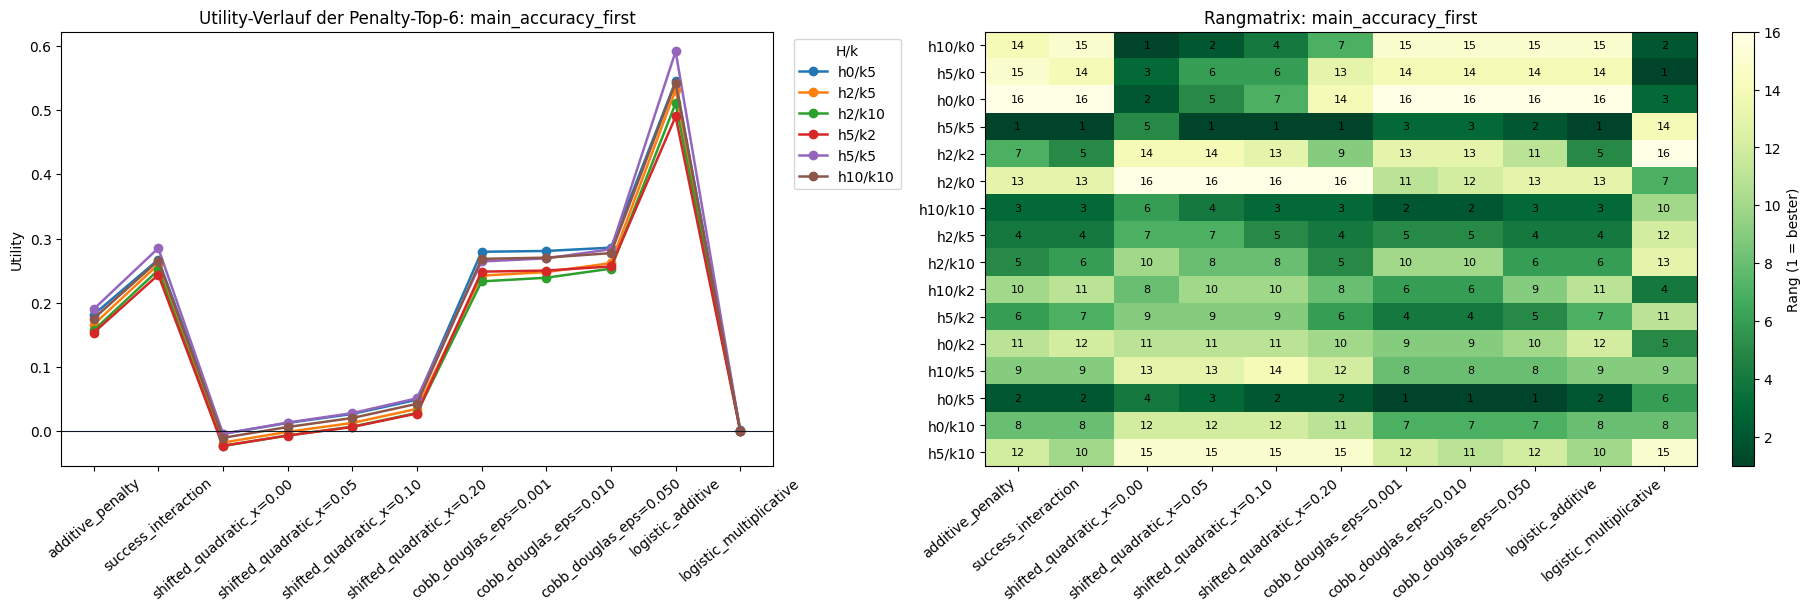

In [88]:
SELECTED_PERSONA = "main_accuracy_first"
TOP_HK = (
    baseline[baseline["persona"].eq(SELECTED_PERSONA)]
    .sort_values("rank")
    .head(6)["hk"]
    .tolist()
)

plot_df = utility_long[
    utility_long["persona"].eq(SELECTED_PERSONA) & utility_long["hk"].isin(TOP_HK)
].copy()

formula_order = [
    "additive_penalty", "success_interaction",
    *[f"shifted_quadratic_x={x:.2f}" for x in QUADRATIC_X_VALUES],
    *[f"cobb_douglas_eps={eps:.3f}" for eps in COBB_EPSILON_VALUES],
    "logistic_additive", "logistic_multiplicative",
]
plot_df["formula"] = pd.Categorical(plot_df["formula"], categories=formula_order, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)
for hk, group in plot_df.groupby("hk", sort=False):
    group = group.sort_values("formula")
    axes[0].plot(group["formula"].astype(str), group["utility"], marker="o", linewidth=1.8, label=hk)
axes[0].axhline(0, color="#111827", linewidth=0.8)
axes[0].tick_params(axis="x", rotation=40)
axes[0].set_title(f"Utility-Verlauf der Penalty-Top-6: {SELECTED_PERSONA}")
axes[0].set_ylabel("Utility")
axes[0].legend(title="H/k", bbox_to_anchor=(1.02, 1), loc="upper left")

rank_matrix, _ = rank_comparison_table(utility_long, SELECTED_PERSONA)
rank_matrix = rank_matrix.drop(columns=["rank_range", "best_rank", "worst_rank"]).reindex(columns=formula_order)
image = axes[1].imshow(rank_matrix.to_numpy(dtype=float), cmap="YlGn_r", aspect="auto")
axes[1].set_title(f"Rangmatrix: {SELECTED_PERSONA}")
axes[1].set_xticks(range(len(rank_matrix.columns)), rank_matrix.columns, rotation=40, ha="right")
axes[1].set_yticks(range(len(rank_matrix.index)), rank_matrix.index)
for row in range(rank_matrix.shape[0]):
    for col in range(rank_matrix.shape[1]):
        axes[1].text(col, row, f"{rank_matrix.iloc[row, col]:.0f}", ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=axes[1], label="Rang (1 = bester)")
plt.show()


## 8. Parameter-Sensitivität

Hier werden die Funktionsformen selbst sichtbar. Die rechte Tabelle zeigt für die beste H/k-Kombination der Penalty-Referenz, ob die Wahl von $x$ oder $\varepsilon$ die Rangfolge verändert.


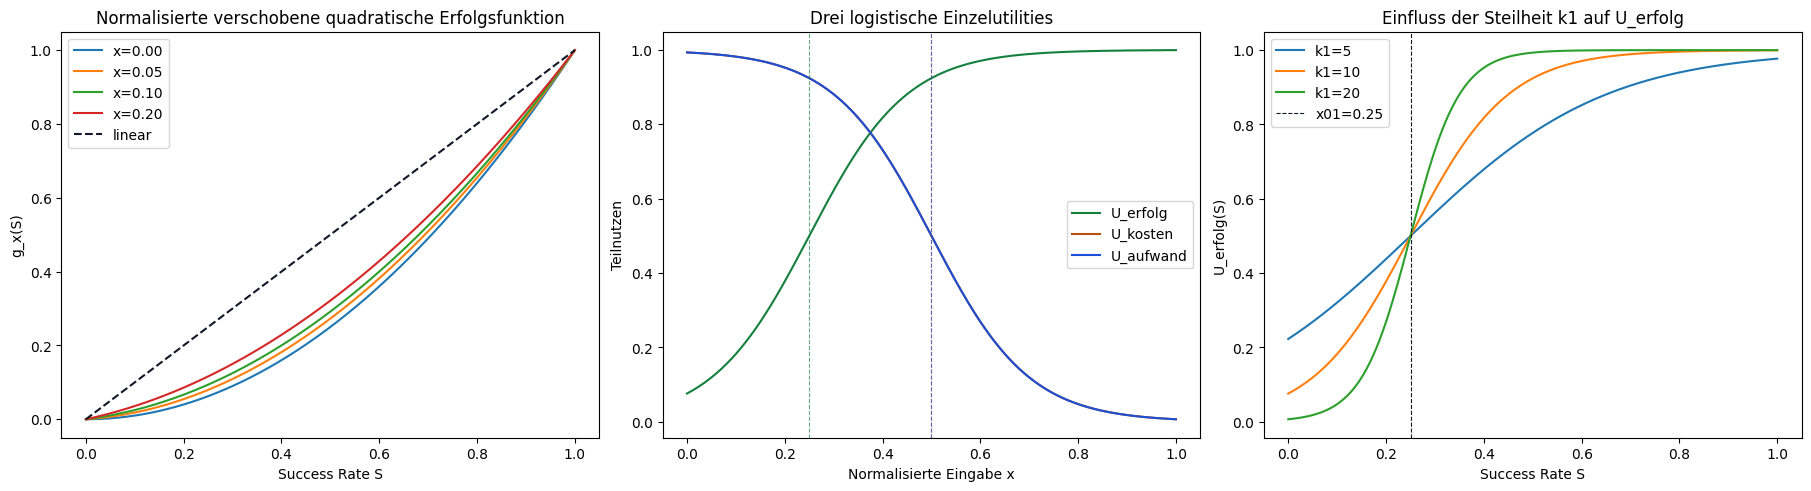

### Logistische Komponenten fuer Penalty-Referenzgewinner `h5/k5`

`U_erfolg`, `U_kosten` und `U_aufwand` sind die drei separaten logistischen Werte. Die additive Utility nutzt die Persona-Gewichte; die multiplikative Utility ist das reine Produkt der drei Komponenten.

,hk,success_rate_pct,avg_tokens_k,avg_runtime_s,T_norm,runtime_norm,U_erfolg,U_kosten,U_aufwand,U_logistisch_additiv_main_accuracy_first,U_logistisch_additiv_cost_sensitive,U_logistisch_additiv_time_sensitive,U_logistisch_additiv_stress_80,U_logistisch_multiplikativ
10,h5/k5,31.4%,876.8k,317.8s,0.974,0.886,0.6554,0.0086,0.0207,0.5913,0.5267,0.5279,0.4952,0.0001


In [89]:
success_grid = np.linspace(0, 1, 300)
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), constrained_layout=True)
for x in QUADRATIC_X_VALUES:
    axes[0].plot(success_grid, shifted_quadratic_success(success_grid, x), label=f"x={x:.2f}")
axes[0].plot(success_grid, success_grid, linestyle="--", color="#111827", label="linear")
axes[0].set_title("Normalisierte verschobene quadratische Erfolgsfunktion")
axes[0].set_xlabel("Success Rate S")
axes[0].set_ylabel("g_x(S)")
axes[0].legend()

axes[1].plot(success_grid, utility_success_logistic(success_grid, LOGISTIC_DEFAULT["x01"], LOGISTIC_DEFAULT["k1"]), label="U_erfolg", color="#15803d")
axes[1].plot(success_grid, utility_cost_logistic(success_grid, LOGISTIC_DEFAULT["x02"], LOGISTIC_DEFAULT["k2"]), label="U_kosten", color="#b45309")
axes[1].plot(success_grid, utility_effort_logistic(success_grid, LOGISTIC_DEFAULT["x03"], LOGISTIC_DEFAULT["k3"]), label="U_aufwand", color="#1d4ed8")
for midpoint, color in [(LOGISTIC_DEFAULT["x01"], "#15803d"), (LOGISTIC_DEFAULT["x02"], "#b45309"), (LOGISTIC_DEFAULT["x03"], "#1d4ed8")]:
    axes[1].axvline(midpoint, linestyle="--", color=color, linewidth=0.8, alpha=0.65)
axes[1].set_title("Drei logistische Einzelutilities")
axes[1].set_xlabel("Normalisierte Eingabe x")
axes[1].set_ylabel("Teilnutzen")
axes[1].legend()

for k in [5, 10, 20]:
    axes[2].plot(success_grid, utility_success_logistic(success_grid, LOGISTIC_DEFAULT["x01"], k), label=f"k1={k}")
axes[2].axvline(LOGISTIC_DEFAULT["x01"], linestyle="--", color="#111827", linewidth=0.8, label=f"x01={LOGISTIC_DEFAULT['x01']:.2f}")
axes[2].set_title("Einfluss der Steilheit k1 auf U_erfolg")
axes[2].set_xlabel("Success Rate S")
axes[2].set_ylabel("U_erfolg(S)")
axes[2].legend()
plt.show()

reference_hk = baseline[baseline["persona"].eq(SELECTED_PERSONA)].sort_values("rank").iloc[0]["hk"]
reference_rows = hk_df[hk_df["hk"].eq(reference_hk)].copy()
logistic_detail = reference_rows[["hk", "success_rate_pct", "avg_tokens_k", "avg_runtime_s", "T_norm", "runtime_norm"]].join(
    logistic_components(reference_rows, **LOGISTIC_DEFAULT)
)
for persona, weights in PERSONAS.items():
    logistic_detail[f"U_logistisch_additiv_{persona}"] = utility_logistic_additive(reference_rows, **weights, **LOGISTIC_DEFAULT)
logistic_detail["U_logistisch_multiplikativ"] = utility_logistic_multiplicative(
    reference_rows,
    **PERSONAS[SELECTED_PERSONA],
    **LOGISTIC_DEFAULT,
)

display(Markdown(f"### Logistische Komponenten fuer Penalty-Referenzgewinner `{reference_hk}`"))
display(Markdown(
    "`U_erfolg`, `U_kosten` und `U_aufwand` sind die drei separaten logistischen Werte. "
    "Die additive Utility nutzt die Persona-Gewichte; die multiplikative Utility ist das reine Produkt der drei Komponenten."
))
display(logistic_detail.style.format({
    "success_rate_pct": "{:.1f}%", "avg_tokens_k": "{:.1f}k", "avg_runtime_s": "{:.1f}s",
    "T_norm": "{:.3f}", "runtime_norm": "{:.3f}", "U_erfolg": "{:.4f}", "U_kosten": "{:.4f}", "U_aufwand": "{:.4f}",
    **{col: "{:.4f}" for col in logistic_detail.columns if col.startswith("U_logistisch_")},
}).background_gradient(subset=["U_erfolg", "U_kosten", "U_aufwand", "U_logistisch_multiplikativ"], cmap="YlGn"))


## 9. Cobb-Douglas-Gewichtungsraum: Entwicklung aller H/k-Kombinationen

Die folgende Analyse verwendet die exakte Cobb-Douglas-Form:

$$
U(H,k)=S(H,k)^\alpha\cdot\left(1-\tau_{norm}(H,k)\right)^\beta\cdot\left(1-T_{norm}(H,k)\right)^\gamma
$$

Dabei ist $A=1$. In dieser Formel steht $\beta$ für die Laufzeit- bzw. Aufwandselastizität und $\gamma$ für die Token- bzw. Kostenelastizität.

Für die Visualisierung wird das zulässige Gewichtsdreieck verwendet:

$$
\alpha+\beta+\gamma=1,\qquad\alpha\geq0.75,\qquad\beta+\gamma\leq0.25
$$

Die Gewinnerkarte zeigt für jeden Gewichtungspunkt, welche H/k-Kombination die höchste Cobb-Douglas-Utility besitzt. Die Detailkarten zeigen den Utility-Verlauf für die drei stabilsten Kandidaten, nicht nur für einen einzelnen Gewinner.

Hinweis: Die Hauptkarten verwenden $\varepsilon=0$, also die exakte Formel. H/k-Kombinationen mit $T_{norm}=1$ oder $\tau_{norm}=1$ können dadurch bei positivem jeweiligen Exponenten Utility `0` erhalten. Die oben verwendeten `epsilon`-Varianten bleiben als stabilisierte Sensitivität erhalten.


**Gewichtungspunkte:** 351 | **Utility-Werte exakt 0:** 6.2%

### 9.1 Stabilste H/k-Kombinationen im Cobb-Douglas-Gewichtungsraum

,hk,h,k,win_count,mean_winning_utility,min_winning_utility,max_winning_utility,success_rate_pct,avg_tokens_k,avg_runtime_s,win_share_pct
0,h0/k5,0,5,324,0.2709,0.2487,0.2856,29.0%,774.7k,279.7s,92.3%
1,h5/k5,5,5,27,0.2958,0.2844,0.3143,31.4%,876.8k,317.8s,7.7%


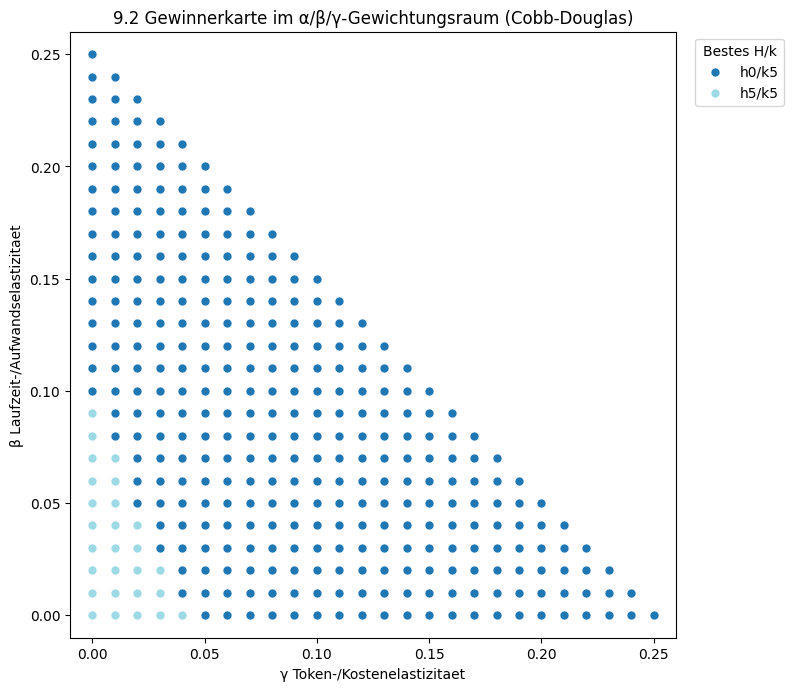

### 9.3 Utility-Entwicklung der stabilsten Top-3-H/k-Kombinationen

Die Farbe zeigt pro H/k-Kombination die Cobb-Douglas-Utility über alle zulässigen Gewichtungen. Die X-Marker zeigen die festen Persona-Profile; ihre Lage wird von `β` Token und `γ` Laufzeit aus der bisherigen Persona-Definition in die Formelachsen überführt.

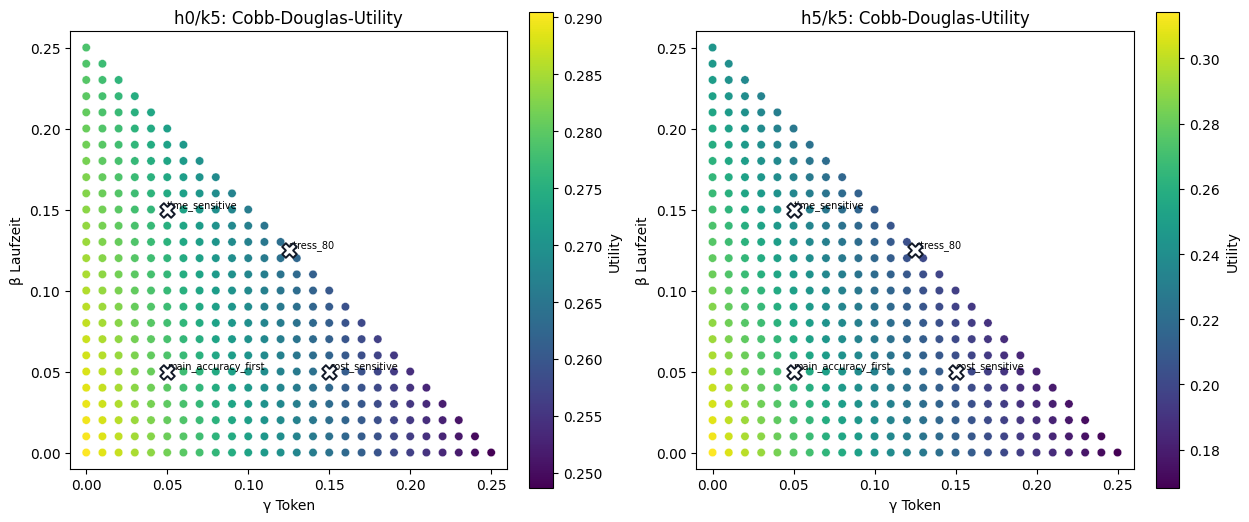

### 9.4 Cobb-Douglas-Rangfolge an den festen Persona-Punkten

,persona,rank,hk,alpha,beta_runtime,gamma_token,success_rate_pct,avg_tokens_k,avg_runtime_s,utility
18,cost_sensitive,1,h0/k5,0.800,0.050,0.150,29.0%,774.7k,279.7s,0.2624
17,cost_sensitive,2,h0/k2,0.800,0.050,0.150,23.8%,675.7k,291.4s,0.2424
29,cost_sensitive,3,h10/k2,0.800,0.050,0.150,23.8%,705.5k,268.5s,0.2411
31,cost_sensitive,4,h10/k10,0.800,0.050,0.150,29.0%,823.9k,298.0s,0.2394
25,cost_sensitive,5,h5/k2,0.800,0.050,0.150,26.7%,814.0k,304.4s,0.2264
19,cost_sensitive,6,h0/k10,0.800,0.050,0.150,25.2%,812.3k,290.0s,0.2202
30,cost_sensitive,7,h10/k5,0.800,0.050,0.150,25.2%,811.8k,292.2s,0.2200
26,cost_sensitive,8,h5/k5,0.800,0.050,0.150,31.4%,876.8k,317.8s,0.2053
20,cost_sensitive,9,h2/k0,0.800,0.050,0.150,21.0%,762.6k,287.3s,0.2038
22,cost_sensitive,10,h2/k5,0.800,0.050,0.150,28.6%,883.1k,304.7s,0.1830


In [90]:
COBB_WEIGHT_STEP = 0.01
COBB_EXACT_EPSILON = 0.0


def make_cobb_weight_grid(step=COBB_WEIGHT_STEP):
    rows = []
    values = np.round(np.arange(0.0, 0.25 + step / 2, step), 6)
    for beta_runtime in values:
        for gamma_token in values:
            alpha = round(1.0 - beta_runtime - gamma_token, 6)
            if alpha < 0.75 - 1e-9:
                continue
            rows.append({
                "alpha": alpha,
                "beta_runtime": beta_runtime,
                "gamma_token": gamma_token,
            })
    return pd.DataFrame(rows)


def compute_cobb_weight_space(hk_table, weight_grid, epsilon=0.0):
    candidates = hk_table[[
        "hk", "h", "k", "success_rate", "success_rate_pct", "avg_tokens_k", "avg_runtime_s", "T_norm", "runtime_norm"
    ]].copy()
    space = weight_grid.assign(_join=1).merge(candidates.assign(_join=1), on="_join").drop(columns="_join")
    token_efficiency = (epsilon + 1 - space["T_norm"]).clip(lower=epsilon)
    runtime_efficiency = (epsilon + 1 - space["runtime_norm"]).clip(lower=epsilon)
    space["utility"] = (
        space["success_rate"].clip(lower=0) ** space["alpha"]
        * runtime_efficiency ** space["beta_runtime"]
        * token_efficiency ** space["gamma_token"]
    )
    return space


def select_cobb_winners(weight_space):
    return (
        weight_space.sort_values(
            ["alpha", "beta_runtime", "gamma_token", "utility", "success_rate", "avg_tokens_k", "avg_runtime_s"],
            ascending=[True, True, True, False, False, True, True],
        )
        .groupby(["alpha", "beta_runtime", "gamma_token"], as_index=False)
        .head(1)
        .reset_index(drop=True)
    )


def summarize_cobb_winners(winners):
    total = max(len(winners), 1)
    return (
        winners.groupby(["hk", "h", "k"], dropna=False)
        .agg(
            win_count=("utility", "size"),
            mean_winning_utility=("utility", "mean"),
            min_winning_utility=("utility", "min"),
            max_winning_utility=("utility", "max"),
            success_rate_pct=("success_rate_pct", "first"),
            avg_tokens_k=("avg_tokens_k", "first"),
            avg_runtime_s=("avg_runtime_s", "first"),
        )
        .reset_index()
        .assign(win_share_pct=lambda df: df["win_count"] / total * 100)
        .sort_values(["win_share_pct", "mean_winning_utility"], ascending=[False, False])
        .reset_index(drop=True)
    )


def plot_cobb_winner_map(winners, title):
    categories = winners["hk"].drop_duplicates().tolist()
    cmap = plt.get_cmap("tab20", max(len(categories), 1))
    color_map = {hk: cmap(i) for i, hk in enumerate(categories)}

    fig, ax = plt.subplots(figsize=(9.2, 6.8), constrained_layout=True)
    for hk in categories:
        part = winners[winners["hk"].eq(hk)]
        ax.scatter(
            part["gamma_token"], part["beta_runtime"], s=42,
            color=color_map[hk], edgecolor="white", linewidth=0.45, label=hk,
        )
    ax.set_title(title)
    ax.set_xlabel("γ Token-/Kostenelastizitaet")
    ax.set_ylabel("β Laufzeit-/Aufwandselastizitaet")
    ax.set_xlim(-0.01, 0.26)
    ax.set_ylim(-0.01, 0.26)
    ax.set_aspect("equal")
    ax.legend(title="Bestes H/k", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.show()


def plot_cobb_candidate_maps(weight_space, candidate_hks, max_candidates=3):
    candidate_hks = list(candidate_hks)[:max_candidates]
    fig, axes = plt.subplots(1, len(candidate_hks), figsize=(6.2 * len(candidate_hks), 5.2), constrained_layout=True)
    if len(candidate_hks) == 1:
        axes = [axes]

    for ax, hk in zip(axes, candidate_hks):
        part = weight_space[weight_space["hk"].eq(hk)]
        scatter = ax.scatter(
            part["gamma_token"], part["beta_runtime"], c=part["utility"],
            cmap="viridis", s=36, edgecolor="white", linewidth=0.25,
        )
        for persona, weights in PERSONAS.items():
            # In der Formel: beta=Runtime, gamma=Tokens; in den Personas: beta=Tokens, gamma=Runtime.
            ax.scatter(
                weights["beta"], weights["gamma"], marker="X", s=110,
                color="white", edgecolor="#111827", linewidth=1.4, zorder=4,
            )
            ax.text(weights["beta"], weights["gamma"], persona, fontsize=7, va="bottom")
        ax.set_title(f"{hk}: Cobb-Douglas-Utility")
        ax.set_xlabel("γ Token")
        ax.set_ylabel("β Laufzeit")
        ax.set_xlim(-0.01, 0.26)
        ax.set_ylim(-0.01, 0.26)
        ax.set_aspect("equal")
        fig.colorbar(scatter, ax=ax, label="Utility")
    plt.show()


cobb_weight_grid = make_cobb_weight_grid()
cobb_weight_space = compute_cobb_weight_space(hk_df, cobb_weight_grid, epsilon=COBB_EXACT_EPSILON)
cobb_winners = select_cobb_winners(cobb_weight_space)
cobb_winner_summary = summarize_cobb_winners(cobb_winners)
cobb_top3_hks = cobb_winner_summary.head(3)["hk"].tolist()

zero_share = (cobb_weight_space["utility"].eq(0).mean() * 100)
display(Markdown(f"**Gewichtungspunkte:** {len(cobb_weight_grid)} | **Utility-Werte exakt 0:** {zero_share:.1f}%"))
display(Markdown("### 9.1 Stabilste H/k-Kombinationen im Cobb-Douglas-Gewichtungsraum"))
display(cobb_winner_summary.style.format({
    "win_count": "{:.0f}", "win_share_pct": "{:.1f}%", "mean_winning_utility": "{:.4f}",
    "min_winning_utility": "{:.4f}", "max_winning_utility": "{:.4f}", "success_rate_pct": "{:.1f}%",
    "avg_tokens_k": "{:.1f}k", "avg_runtime_s": "{:.1f}s",
}).background_gradient(subset=["win_share_pct", "mean_winning_utility"], cmap="YlGn"))

plot_cobb_winner_map(cobb_winners, "9.2 Gewinnerkarte im α/β/γ-Gewichtungsraum (Cobb-Douglas)")

display(Markdown("### 9.3 Utility-Entwicklung der stabilsten Top-3-H/k-Kombinationen"))
display(Markdown(
    "Die Farbe zeigt pro H/k-Kombination die Cobb-Douglas-Utility über alle zulässigen Gewichtungen. "
    "Die X-Marker zeigen die festen Persona-Profile; ihre Lage wird von `β` Token und `γ` Laufzeit aus der bisherigen Persona-Definition in die Formelachsen überführt."
))
plot_cobb_candidate_maps(cobb_weight_space, cobb_top3_hks)

cobb_persona_rows = []
for persona, weights in PERSONAS.items():
    # Formelachsen: beta_runtime=Persona-gamma, gamma_token=Persona-beta.
    selected = cobb_weight_space[
        np.isclose(cobb_weight_space["alpha"], weights["alpha"])
        & np.isclose(cobb_weight_space["beta_runtime"], weights["gamma"])
        & np.isclose(cobb_weight_space["gamma_token"], weights["beta"])
    ].copy()
    if selected.empty:
        continue
    selected["persona"] = persona
    selected["rank"] = selected["utility"].rank(method="min", ascending=False).astype(int)
    cobb_persona_rows.append(selected)

cobb_persona_table = pd.concat(cobb_persona_rows, ignore_index=True)
display(Markdown("### 9.4 Cobb-Douglas-Rangfolge an den festen Persona-Punkten"))
display(cobb_persona_table.sort_values(["persona", "rank"])[[
    "persona", "rank", "hk", "alpha", "beta_runtime", "gamma_token", "success_rate_pct", "avg_tokens_k", "avg_runtime_s", "utility"
]].style.format({
    "alpha": "{:.3f}", "beta_runtime": "{:.3f}", "gamma_token": "{:.3f}", "success_rate_pct": "{:.1f}%",
    "avg_tokens_k": "{:.1f}k", "avg_runtime_s": "{:.1f}s", "utility": "{:.4f}", "rank": "{:.0f}",
}))


## 9. Formale Einordnung

* Rangwechsel zeigen Sensitivität gegenüber Modellannahmen, nicht automatisch eine bessere Formel.
* Die additive Penalty-Utility ist direkt interpretierbar, kann aber negative Werte erzeugen.
* Die Wechselwirkungs-Utility verhindert, dass Effizienz bei geringer Success Rate stark kompensiert.
* Die quadratische Variante belohnt hohe Success Rates stärker; $x$ kontrolliert die Reaktion im unteren Erfolgsbereich.
* Cobb-Douglas und logistische Multiplikation sind weniger kompensatorisch, aber stärker von $\varepsilon$, Schwellen und Steilheiten abhängig.
* Eine spätere Wahl einer Formel sollte über nachvollziehbare Annahmen und Stabilität der Rangfolge begründet werden, nicht nur über den jeweils höchsten Einzelwert.


## 10. Logistische Nutzenfunktionen und Schwellenwertanalyse

Dieser Abschnitt ergänzt die vorhandenen Berechnungen, ohne sie zu verändern. Er verwendet die bereits aggregierten H/k-Werte für Success Rate, durchschnittliche Tokens und durchschnittliche Laufzeit.

Für die drei Dimensionen gelten:

$$
U_S(S)=\frac{1}{1+\exp[-k_1(S-S_0)]}
$$

$$
U_K(K)=\frac{1}{1+\exp[k_2(K-K_0)]}
$$

$$
U_A(A)=\frac{1}{1+\exp[k_3(A-A_0)]}
$$

Success Rate liegt bereits in $[0,1]$. Als **Kosten-Proxy** wird der durchschnittliche Tokenverbrauch verwendet; Aufwand wird durch die durchschnittliche Laufzeit gemessen. Kosten-Proxy und Aufwand werden nur für die logistische Transformation auf $[0,1]$ normalisiert; alle Schwellen werden zusätzlich in Tokens bzw. Sekunden ausgegeben.

Der Wendepunkt $x_0$ markiert jeweils die größte Veränderung: Dort ist der Betrag der ersten Ableitung maximal. Die Analyse betrachtet mehrere Steilheiten $k$, damit sichtbar bleibt, wie stark die Schlussfolgerungen von der Kalibrierung abhängen.


In [91]:
# --- Datenquelle automatisch erkennen; bestehende Tabellen bleiben unveraendert. ---
def _find_logistic_hk_table(namespace):
    preferred_names = ["hk_df", "hk_global"]
    required = {"success_rate"}
    for name in preferred_names:
        candidate = namespace.get(name)
        if isinstance(candidate, pd.DataFrame) and required.issubset(candidate.columns):
            return name, candidate.copy()

    for name, candidate in namespace.items():
        if not isinstance(candidate, pd.DataFrame) or not required.issubset(candidate.columns):
            continue
        has_tokens = "avg_tokens" in candidate.columns or "avg_tokens_k" in candidate.columns
        has_runtime = "avg_runtime_s" in candidate.columns or "runtime_s" in candidate.columns
        if has_tokens and has_runtime:
            return name, candidate.copy()
    raise KeyError("Keine aggregierte H/k-Tabelle mit Success, Tokens und Laufzeit gefunden.")


LOGISTIC_SOURCE_NAME, logistic_hk_df = _find_logistic_hk_table(globals())

if "hk" not in logistic_hk_df.columns:
    if {"h", "k"}.issubset(logistic_hk_df.columns):
        logistic_hk_df["hk"] = "h" + logistic_hk_df["h"].astype(int).astype(str) + "/k" + logistic_hk_df["k"].astype(int).astype(str)
    else:
        logistic_hk_df["hk"] = logistic_hk_df.index.astype(str)

KOSTEN_COLUMN = "avg_tokens" if "avg_tokens" in logistic_hk_df.columns else "avg_tokens_k"
AUFWAND_COLUMN = "avg_runtime_s" if "avg_runtime_s" in logistic_hk_df.columns else "runtime_s"
KOSTEN_UNIT_LABEL = "Tokens (Kosten-Proxy)" if KOSTEN_COLUMN == "avg_tokens" else "Tokens in k (Kosten-Proxy)"

logistic_hk_df = logistic_hk_df[["hk", "success_rate", KOSTEN_COLUMN, AUFWAND_COLUMN]].copy()
logistic_hk_df = logistic_hk_df.rename(columns={KOSTEN_COLUMN: "kosten_raw", AUFWAND_COLUMN: "aufwand_s_raw"})
logistic_hk_df["success_rate"] = pd.to_numeric(logistic_hk_df["success_rate"], errors="coerce")
logistic_hk_df["kosten_raw"] = pd.to_numeric(logistic_hk_df["kosten_raw"], errors="coerce")
logistic_hk_df["aufwand_s_raw"] = pd.to_numeric(logistic_hk_df["aufwand_s_raw"], errors="coerce")
logistic_hk_df = logistic_hk_df.dropna(subset=["success_rate", "kosten_raw", "aufwand_s_raw"]).reset_index(drop=True)


def minmax_with_metadata(values):
    values = pd.to_numeric(values, errors="coerce").astype(float)
    lo, hi = float(values.min()), float(values.max())
    if np.isclose(lo, hi):
        normalized = pd.Series(0.5, index=values.index)
    else:
        normalized = (values - lo) / (hi - lo)
    return normalized.clip(0, 1), lo, hi


def normalize_raw(value, lo, hi):
    if np.isclose(lo, hi):
        return 0.5
    return float(np.clip((value - lo) / (hi - lo), 0, 1))


def denormalize_value(value, lo, hi):
    return float(lo + np.clip(value, 0, 1) * (hi - lo))


logistic_hk_df["kosten_norm"], KOSTEN_MIN, KOSTEN_MAX = minmax_with_metadata(logistic_hk_df["kosten_raw"])
logistic_hk_df["aufwand_norm"], AUFWAND_MIN, AUFWAND_MAX = minmax_with_metadata(logistic_hk_df["aufwand_s_raw"])

# Diese drei Rohwerte sind die bewusst leicht editierbaren Schwellen. Standard: Median der beobachteten Werte.
S0 = float(logistic_hk_df["success_rate"].median())
K0_RAW = float(logistic_hk_df["kosten_raw"].median())
A0_RAW = float(logistic_hk_df["aufwand_s_raw"].median())

K0 = normalize_raw(K0_RAW, KOSTEN_MIN, KOSTEN_MAX)
A0 = normalize_raw(A0_RAW, AUFWAND_MIN, AUFWAND_MAX)

# Diese Gewichte sind separat von den bestehenden Persona-Berechnungen und gelten nur für diesen Abschnitt.
alpha, beta, gamma = 0.90, 0.05, 0.05
k_values = [5, 10, 20, 40]

threshold_overview = pd.DataFrame([
    {"dimension": "Success", "threshold_norm": S0, "threshold_original": S0, "unit": "Success Rate"},
    {"dimension": "Kosten", "threshold_norm": K0, "threshold_original": K0_RAW, "unit": KOSTEN_UNIT_LABEL},
    {"dimension": "Aufwand/Zeit", "threshold_norm": A0, "threshold_original": A0_RAW, "unit": "Sekunden"},
])

display(Markdown(f"**Verwendete Aggregation:** `{LOGISTIC_SOURCE_NAME}` | **H/k-Kombinationen:** {len(logistic_hk_df)}"))
display(Markdown("**Editierbare Standardparameter:** `S0`, `K0_RAW`, `A0_RAW`, `alpha`, `beta`, `gamma`, `k_values`."))
display(threshold_overview.style.format({"threshold_norm": "{:.4f}", "threshold_original": "{:.2f}"}))


**Verwendete Aggregation:** `hk_df` | **H/k-Kombinationen:** 16

**Editierbare Standardparameter:** `S0`, `K0_RAW`, `A0_RAW`, `alpha`, `beta`, `gamma`, `k_values`.

,dimension,threshold_norm,threshold_original,unit
0,Success,0.2524,0.25,Success Rate
1,Kosten,0.8916,812045.30,Tokens (Kosten-Proxy)
2,Aufwand/Zeit,0.7962,291.83,Sekunden


### 10.1 Schwellenwerte und Grenznutzenbereiche

,dimension,k,wendepunkt_norm,wendepunkt_original,max_steigung_betrag,bereich_50pct_unten_norm,bereich_50pct_oben_norm,bereich_50pct_unten_original,bereich_50pct_oben_original,saettigung_unten_norm,saettigung_oben_norm,saettigung_unten_original,saettigung_oben_original,abnehmender_grenznutzen_ab_norm,abnehmender_grenznutzen_ab_original,interpretation,einheit
0,Success,5,0.2524,0.25,1.250,0.0000,0.6049,0.00,0.60,0.0000,0.9798,0.00,0.98,0.9798,0.98,ab dieser Success Rate bringen weitere Steigerungen nur wenig Zusatznutzen,Success Rate
1,Success,10,0.2524,0.25,2.500,0.0761,0.4287,0.08,0.43,0.0000,0.6161,0.00,0.62,0.6161,0.62,ab dieser Success Rate bringen weitere Steigerungen nur wenig Zusatznutzen,Success Rate
2,Success,20,0.2524,0.25,5.000,0.1642,0.3405,0.16,0.34,0.0705,0.4342,0.07,0.43,0.4342,0.43,ab dieser Success Rate bringen weitere Steigerungen nur wenig Zusatznutzen,Success Rate
3,Success,40,0.2524,0.25,10.000,0.2083,0.2964,0.21,0.30,0.1615,0.3433,0.16,0.34,0.3433,0.34,ab dieser Success Rate bringen weitere Steigerungen nur wenig Zusatznutzen,Success Rate
4,Kosten,5,0.8916,812045.30,1.250,0.5391,1.0000,535676.83,897020.63,0.1642,1.0000,241842.97,897020.63,0.1642,241842.97,unter diesem Wert bringen weitere Reduktionen nur wenig Zusatznutzen,Tokens (Kosten-Proxy)
5,Kosten,10,0.8916,812045.30,2.500,0.7153,1.0000,673861.07,897020.63,0.5279,1.0000,526944.14,897020.63,0.5279,526944.14,unter diesem Wert bringen weitere Reduktionen nur wenig Zusatznutzen,Tokens (Kosten-Proxy)
6,Kosten,20,0.8916,812045.30,5.000,0.8035,0.9797,742953.18,881137.42,0.7098,1.0000,669494.72,897020.63,0.7098,669494.72,unter diesem Wert bringen weitere Reduktionen nur wenig Zusatznutzen,Tokens (Kosten-Proxy)
7,Kosten,40,0.8916,812045.30,10.000,0.8475,0.9357,777499.24,846591.36,0.8007,0.9825,740770.01,883320.59,0.8007,740770.01,unter diesem Wert bringen weitere Reduktionen nur wenig Zusatznutzen,Tokens (Kosten-Proxy)
8,Aufwand/Zeit,5,0.7962,291.83,1.250,0.4436,1.0000,189.28,351.11,0.0688,1.0000,80.26,351.11,0.0688,80.26,unter diesem Wert bringen weitere Reduktionen nur wenig Zusatznutzen,Sekunden
9,Aufwand/Zeit,10,0.7962,291.83,2.500,0.6199,0.9725,240.56,343.10,0.4325,1.0000,186.04,351.11,0.4325,186.04,unter diesem Wert bringen weitere Reduktionen nur wenig Zusatznutzen,Sekunden


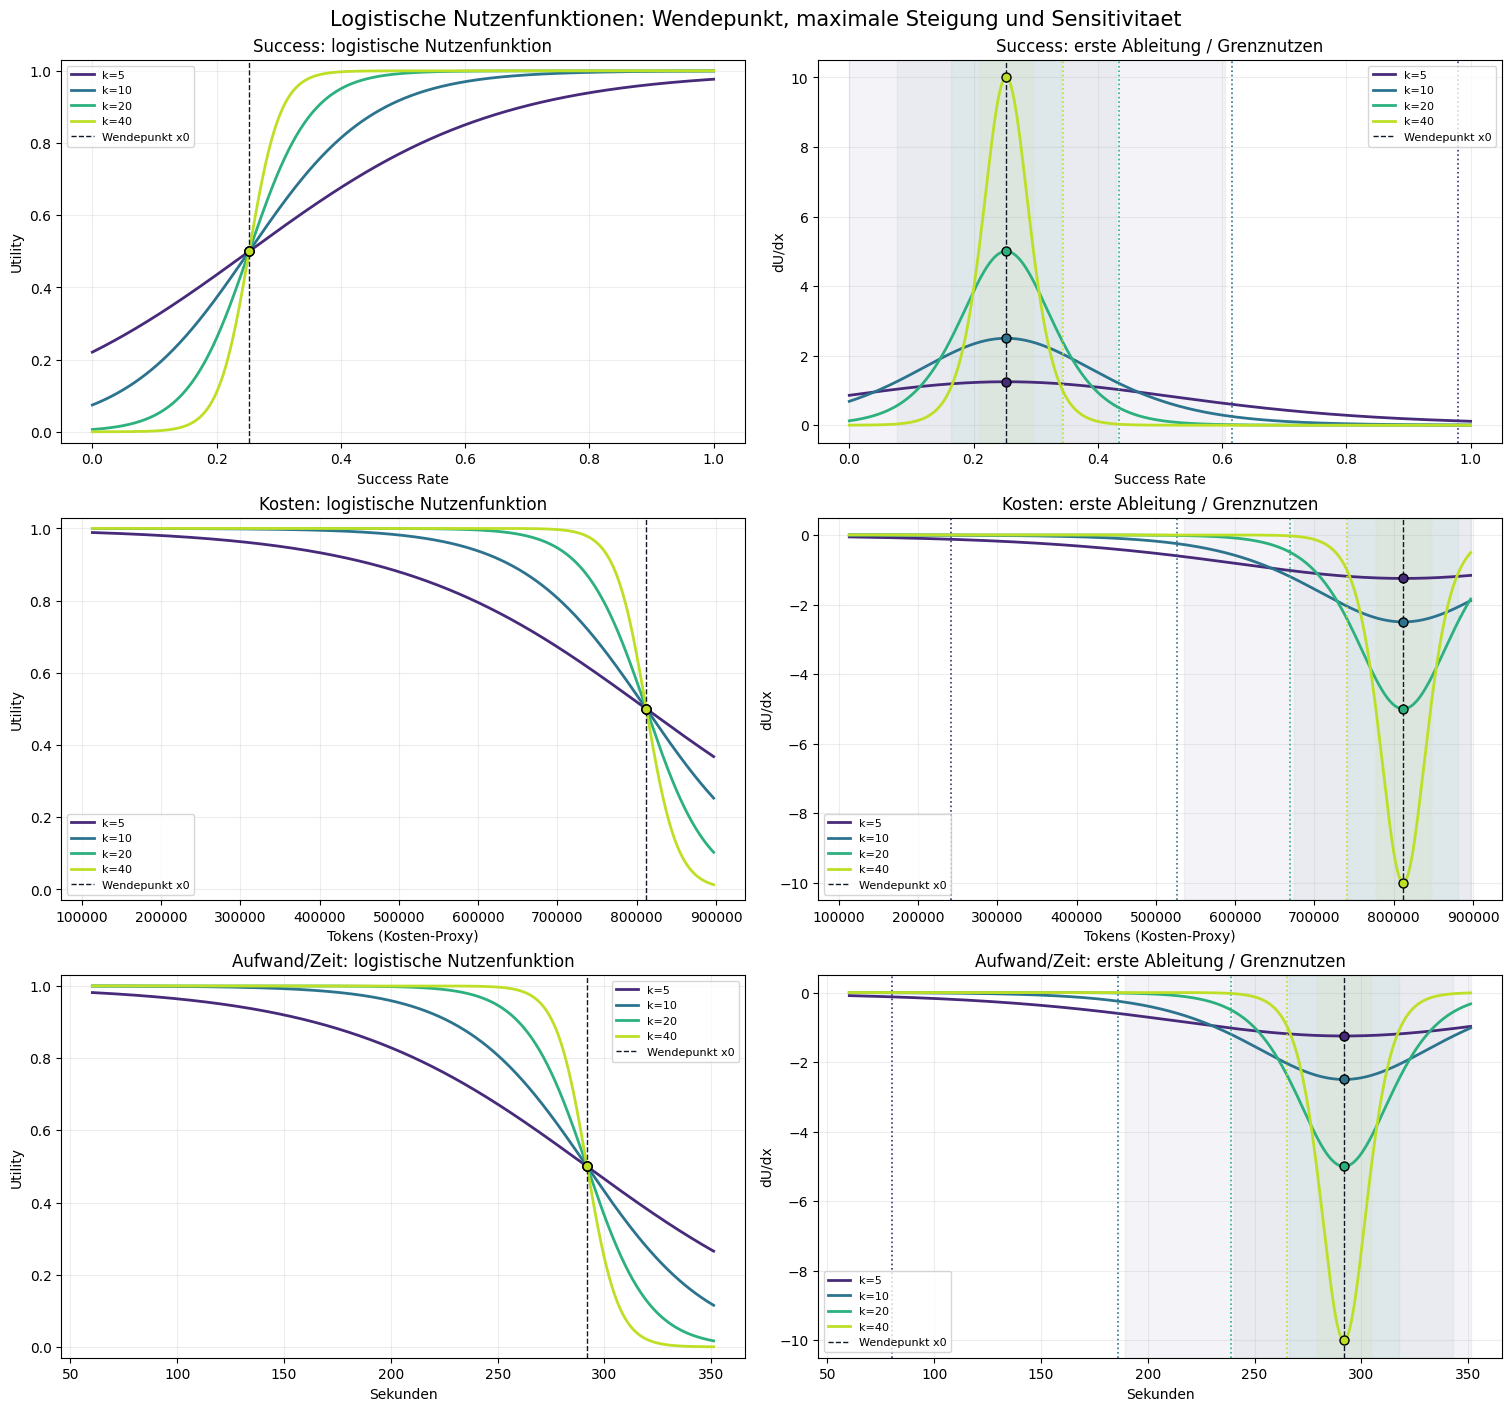

In [92]:
def logistic_success(x, k, x0):
    return 1 / (1 + np.exp(-np.clip(k * (x - x0), -700, 700)))


def logistic_decreasing(x, k, x0):
    return 1 / (1 + np.exp(np.clip(k * (x - x0), -700, 700)))


def logistic_derivative_from_utility(utility, k, direction):
    # direction=+1 fuer Success, direction=-1 fuer Kosten und Laufzeit.
    return direction * k * utility * (1 - utility)


def logistic_thresholds(k, x0, direction, raw_min, raw_max, unit):
    """Analytische Schwellen der logistischen Ableitung.

    |dU/dx| erreicht k/4 bei x0. Bei mindestens 50% der Maximalsteigung
    liegt x innerhalb von x0 +/- logit((1+sqrt(0.5))/2)/k.
    Unter 10% der Maximalsteigung beginnt die Saettigung ausserhalb der
    entsprechenden 10%-Grenzen.
    """
    max_slope = k / 4
    z_50 = float(np.log((1 + np.sqrt(0.5)) / (1 - np.sqrt(0.5))))
    z_10 = float(np.log((1 + np.sqrt(0.9)) / (1 - np.sqrt(0.9))))
    low_50, high_50 = x0 - z_50 / k, x0 + z_50 / k
    low_10, high_10 = x0 - z_10 / k, x0 + z_10 / k

    # Bei Success liegen ab der oberen Sättigung weitere Steigerungen im flachen Bereich.
    # Bei Kosten/Laufzeit liegen unter der unteren Sättigung weitere Reduktionen im flachen Bereich.
    if direction > 0:
        diminishing_norm = high_10
        diminishing_label = "ab dieser Success Rate bringen weitere Steigerungen nur wenig Zusatznutzen"
    else:
        diminishing_norm = low_10
        diminishing_label = "unter diesem Wert bringen weitere Reduktionen nur wenig Zusatznutzen"

    return {
        "max_slope": max_slope,
        "low_50_norm": float(np.clip(low_50, 0, 1)),
        "high_50_norm": float(np.clip(high_50, 0, 1)),
        "low_saturation_norm": float(np.clip(low_10, 0, 1)),
        "high_saturation_norm": float(np.clip(high_10, 0, 1)),
        "diminishing_norm": float(np.clip(diminishing_norm, 0, 1)),
        "diminishing_label": diminishing_label,
        "low_50_original": denormalize_value(low_50, raw_min, raw_max),
        "high_50_original": denormalize_value(high_50, raw_min, raw_max),
        "low_saturation_original": denormalize_value(low_10, raw_min, raw_max),
        "high_saturation_original": denormalize_value(high_10, raw_min, raw_max),
        "diminishing_original": denormalize_value(diminishing_norm, raw_min, raw_max),
        "unit": unit,
    }


DIMENSIONS = {
    "Success": {
        "x0": S0, "raw_min": 0.0, "raw_max": 1.0, "unit": "Success Rate", "direction": 1,
        "utility": lambda x, k: logistic_success(x, k, S0),
    },
    "Kosten": {
        "x0": K0, "raw_min": KOSTEN_MIN, "raw_max": KOSTEN_MAX, "unit": KOSTEN_UNIT_LABEL, "direction": -1,
        "utility": lambda x, k: logistic_decreasing(x, k, K0),
    },
    "Aufwand/Zeit": {
        "x0": A0, "raw_min": AUFWAND_MIN, "raw_max": AUFWAND_MAX, "unit": "Sekunden", "direction": -1,
        "utility": lambda x, k: logistic_decreasing(x, k, A0),
    },
}

# Ergebnistabelle der Wendepunkte, Steigungsbereiche und Saettigung.
threshold_rows = []
for dimension, spec in DIMENSIONS.items():
    for k in k_values:
        metrics = logistic_thresholds(k, spec["x0"], spec["direction"], spec["raw_min"], spec["raw_max"], spec["unit"])
        threshold_rows.append({
            "dimension": dimension,
            "k": k,
            "wendepunkt_norm": spec["x0"],
            "wendepunkt_original": denormalize_value(spec["x0"], spec["raw_min"], spec["raw_max"]),
            "max_steigung_betrag": metrics["max_slope"],
            "bereich_50pct_unten_norm": metrics["low_50_norm"],
            "bereich_50pct_oben_norm": metrics["high_50_norm"],
            "bereich_50pct_unten_original": metrics["low_50_original"],
            "bereich_50pct_oben_original": metrics["high_50_original"],
            "saettigung_unten_norm": metrics["low_saturation_norm"],
            "saettigung_oben_norm": metrics["high_saturation_norm"],
            "saettigung_unten_original": metrics["low_saturation_original"],
            "saettigung_oben_original": metrics["high_saturation_original"],
            "abnehmender_grenznutzen_ab_norm": metrics["diminishing_norm"],
            "abnehmender_grenznutzen_ab_original": metrics["diminishing_original"],
            "interpretation": metrics["diminishing_label"],
            "einheit": metrics["unit"],
        })

logistic_threshold_table = pd.DataFrame(threshold_rows)
display(Markdown("### 10.1 Schwellenwerte und Grenznutzenbereiche"))
display(logistic_threshold_table.style.format({
    "wendepunkt_norm": "{:.4f}", "wendepunkt_original": "{:.2f}", "max_steigung_betrag": "{:.3f}",
    "bereich_50pct_unten_norm": "{:.4f}", "bereich_50pct_oben_norm": "{:.4f}",
    "bereich_50pct_unten_original": "{:.2f}", "bereich_50pct_oben_original": "{:.2f}",
    "saettigung_unten_norm": "{:.4f}", "saettigung_oben_norm": "{:.4f}",
    "saettigung_unten_original": "{:.2f}", "saettigung_oben_original": "{:.2f}",
    "abnehmender_grenznutzen_ab_norm": "{:.4f}", "abnehmender_grenznutzen_ab_original": "{:.2f}",
}).background_gradient(subset=["max_steigung_betrag"], cmap="YlGn"))

# Kurven und erste Ableitungen je Dimension. X-Achsen zeigen Originaleinheiten.
fig, axes = plt.subplots(3, 2, figsize=(15, 14), constrained_layout=True)
colors = plt.cm.viridis(np.linspace(0.12, 0.90, len(k_values)))
for row, (dimension, spec) in enumerate(DIMENSIONS.items()):
    norm_grid = np.linspace(0, 1, 800)
    raw_grid = spec["raw_min"] + norm_grid * (spec["raw_max"] - spec["raw_min"])
    ax_utility, ax_slope = axes[row]

    for k, color in zip(k_values, colors):
        utility = spec["utility"](norm_grid, k)
        derivative = logistic_derivative_from_utility(utility, k, spec["direction"])
        metrics = logistic_thresholds(k, spec["x0"], spec["direction"], spec["raw_min"], spec["raw_max"], spec["unit"])

        ax_utility.plot(raw_grid, utility, color=color, linewidth=2, label=f"k={k}")
        ax_utility.scatter(
            denormalize_value(spec["x0"], spec["raw_min"], spec["raw_max"]), 0.5,
            color=color, edgecolor="black", s=42, zorder=4,
        )
        ax_slope.plot(raw_grid, derivative, color=color, linewidth=2, label=f"k={k}")
        ax_slope.scatter(
            denormalize_value(spec["x0"], spec["raw_min"], spec["raw_max"]), spec["direction"] * metrics["max_slope"],
            color=color, edgecolor="black", s=42, zorder=4,
        )
        ax_slope.axvspan(metrics["low_50_original"], metrics["high_50_original"], color=color, alpha=0.055)
        ax_slope.axvline(metrics["diminishing_original"], color=color, linestyle=":", linewidth=1.2)

    x0_original = denormalize_value(spec["x0"], spec["raw_min"], spec["raw_max"])
    for ax in [ax_utility, ax_slope]:
        ax.axvline(x0_original, color="#111827", linestyle="--", linewidth=1.0, label="Wendepunkt x0")
        ax.grid(alpha=0.22)
        ax.set_xlabel(spec["unit"])
    ax_utility.set_title(f"{dimension}: logistische Nutzenfunktion")
    ax_utility.set_ylabel("Utility")
    ax_utility.set_ylim(-0.03, 1.03)
    ax_slope.set_title(f"{dimension}: erste Ableitung / Grenznutzen")
    ax_slope.set_ylabel("dU/dx")
    ax_utility.legend(loc="best", fontsize=8)
    ax_slope.legend(loc="best", fontsize=8)

fig.suptitle("Logistische Nutzenfunktionen: Wendepunkt, maximale Steigung und Sensitivitaet", fontsize=15)
plt.show()


In [93]:
def build_logistic_rankings(hk_table, k):
    out = hk_table.copy()
    out["U_S"] = logistic_success(out["success_rate"], k, S0)
    out["U_K"] = logistic_decreasing(out["kosten_norm"], k, K0)
    out["U_A"] = logistic_decreasing(out["aufwand_norm"], k, A0)
    out["U_additiv"] = alpha * out["U_S"] + beta * out["U_K"] + gamma * out["U_A"]
    out["U_multiplikativ"] = out["U_S"] * out["U_K"] * out["U_A"]
    out["rang_additiv"] = out["U_additiv"].rank(method="min", ascending=False).astype(int)
    out["rang_multiplikativ"] = out["U_multiplikativ"].rank(method="min", ascending=False).astype(int)
    out["profil"] = np.select(
        [
            (out["U_S"] >= 0.60) & ((out["U_K"] < 0.25) | (out["U_A"] < 0.25)),
            (out["U_S"] < 0.40) & (out["U_K"] >= 0.60) & (out["U_A"] >= 0.60),
        ],
        [
            "hoher Erfolgsnutzen, aber niedriger Kosten- oder Aufwands-/Zeitnutzen",
            "niedriger Erfolgsnutzen, aber hohe Kosten- und Aufwands-/Zeitnutzen",
        ],
        default="ausgeglichen oder intermediär",
    )
    return out.sort_values(["rang_additiv", "rang_multiplikativ", "hk"]).reset_index(drop=True)


logistic_rankings = {k: build_logistic_rankings(logistic_hk_df, k) for k in k_values}
ranking_rows = []
for k, ranking in logistic_rankings.items():
    additive_best = ranking.loc[ranking["rang_additiv"].eq(1)].iloc[0]
    multiplicative_best = ranking.loc[ranking["rang_multiplikativ"].eq(1)].iloc[0]
    ranking_rows.extend([
        {"k": k, "modell": "additiv", "bestes_hk": additive_best["hk"], "utility": additive_best["U_additiv"], "U_S": additive_best["U_S"], "U_K": additive_best["U_K"], "U_A": additive_best["U_A"]},
        {"k": k, "modell": "multiplikativ", "bestes_hk": multiplicative_best["hk"], "utility": multiplicative_best["U_multiplikativ"], "U_S": multiplicative_best["U_S"], "U_K": multiplicative_best["U_K"], "U_A": multiplicative_best["U_A"]},
    ])

logistic_winner_table = pd.DataFrame(ranking_rows)
display(Markdown("### 10.2 Beste Gesamtnutzen je Steilheit und Verknuepfung"))
display(logistic_winner_table.style.format({"utility": "{:.4f}", "U_S": "{:.4f}", "U_K": "{:.4f}", "U_A": "{:.4f}"}).background_gradient(subset=["utility"], cmap="YlGn"))

for k, ranking in logistic_rankings.items():
    display(Markdown(f"### 10.3 Rangliste bei k={k}"))
    display(ranking[[
        "rang_additiv", "rang_multiplikativ", "hk", "success_rate", "kosten_raw", "aufwand_s_raw",
        "U_S", "U_K", "U_A", "U_additiv", "U_multiplikativ", "profil",
    ]].style.format({
        "success_rate": "{:.1%}", "kosten_raw": "{:.1f}", "aufwand_s_raw": "{:.1f}s",
        "U_S": "{:.4f}", "U_K": "{:.4f}", "U_A": "{:.4f}", "U_additiv": "{:.4f}", "U_multiplikativ": "{:.5f}",
    }).background_gradient(subset=["U_S", "U_K", "U_A", "U_additiv", "U_multiplikativ"], cmap="YlGn"))

# Rangstabilitaet als kompakte Vergleichsmatrix.
rank_comparison = []
for k, ranking in logistic_rankings.items():
    rank_comparison.append(ranking[["hk", "rang_additiv", "rang_multiplikativ"]].assign(k=k))
rank_comparison = pd.concat(rank_comparison, ignore_index=True)
rank_matrix_additive = rank_comparison.pivot(index="hk", columns="k", values="rang_additiv")
rank_matrix_multiplicative = rank_comparison.pivot(index="hk", columns="k", values="rang_multiplikativ")

display(Markdown("### 10.4 Rangwechsel ueber die Steilheiten"))
display(Markdown("**Additives Modell**"))
display(rank_matrix_additive.style.format("{:.0f}").background_gradient(cmap="YlGn_r", axis=0))
display(Markdown("**Multiplikatives Modell**"))
display(rank_matrix_multiplicative.style.format("{:.0f}").background_gradient(cmap="YlGn_r", axis=0))

# Automatisch erzeugte, beschreibende Interpretation ohne Auswahl eines einzelnen k-Werts.
interpretation_lines = []
for dimension, spec in DIMENSIONS.items():
    rows = logistic_threshold_table[logistic_threshold_table["dimension"].eq(dimension)]
    k_min = rows["k"].min()
    k_max = rows["k"].max()
    low_wide = rows.loc[rows["k"].eq(k_min)].iloc[0]
    high_narrow = rows.loc[rows["k"].eq(k_max)].iloc[0]
    interpretation_lines.append(
        f"- **{dimension}:** Der Wendepunkt liegt bei {low_wide['wendepunkt_original']:.2f} {low_wide['einheit']}. "
        f"Bei k={k_min} ist der Bereich mit mindestens 50% der Maximalsteigung breit "
        f"({low_wide['bereich_50pct_unten_original']:.2f} bis {low_wide['bereich_50pct_oben_original']:.2f}); "
        f"bei k={k_max} wird er enger ({high_narrow['bereich_50pct_unten_original']:.2f} bis {high_narrow['bereich_50pct_oben_original']:.2f})."
    )

for model in ["additiv", "multiplikativ"]:
    winners = logistic_winner_table[logistic_winner_table["modell"].eq(model)]
    winner_names = winners["bestes_hk"].unique().tolist()
    if len(winner_names) == 1:
        text = f"Im {model}en Modell bleibt `{winner_names[0]}` bei allen untersuchten k-Werten vorn."
    else:
        text = f"Im {model}en Modell wechseln die Spitzenpositionen ueber k zwischen {', '.join(f'`{name}`' for name in winner_names)}."
    interpretation_lines.append(f"- **Rangstabilitaet ({model}):** {text}")

for k, ranking in logistic_rankings.items():
    tradeoffs = ranking[ranking["profil"].eq("hoher Erfolgsnutzen, aber niedriger Kosten- oder Aufwands-/Zeitnutzen")]["hk"].tolist()
    if tradeoffs:
        interpretation_lines.append(
            f"- **k={k}:** {', '.join(f'`{hk}`' for hk in tradeoffs)} zeigt bzw. zeigen hohen Erfolgsnutzen bei gleichzeitig geringerem Kosten- oder Aufwands-/Zeitnutzen."
        )

interpretation_lines.append(
    "- Werte nahe dem Wendepunkt liegen im Bereich der groessten Veraenderung. Werte weit unterhalb oder oberhalb der jeweiligen 10%-Grenzen liegen in der Saettigung; dort ist der Betrag des Grenznutzens klein."
)
display(Markdown("### 10.5 Automatische Interpretation\n\n" + "\n".join(interpretation_lines)))


### 10.2 Beste Gesamtnutzen je Steilheit und Verknuepfung

,k,modell,bestes_hk,utility,U_S,U_K,U_A
0,5,additiv,h5/k5,0.5585,0.5768,0.3982,0.3900
1,5,multiplikativ,h10/k0,0.2984,0.3080,0.9880,0.9807
2,10,additiv,h5/k5,0.6147,0.6500,0.3044,0.2902
3,10,multiplikativ,h10/k2,0.2551,0.4643,0.7957,0.6905
4,20,additiv,h5/k5,0.7129,0.7752,0.1608,0.1432
5,20,multiplikativ,h0/k5,0.3432,0.6818,0.7215,0.6977
6,40,additiv,h5/k5,0.8333,0.9225,0.0354,0.0272
7,40,multiplikativ,h0/k5,0.6017,0.8211,0.8703,0.8419


### 10.3 Rangliste bei k=5

,rang_additiv,rang_multiplikativ,hk,success_rate,kosten_raw,aufwand_s_raw,U_S,U_K,U_A,U_additiv,U_multiplikativ,profil
0,1,13,h5/k5,31.4%,876820.4,317.8s,0.5768,0.3982,0.3900,0.5585,0.08957,ausgeglichen oder intermediär
1,2,6,h0/k5,29.0%,774737.6,279.7s,0.5475,0.5592,0.5521,0.5483,0.16902,ausgeglichen oder intermediär
2,3,9,h10/k10,29.0%,823853.4,298.0s,0.5475,0.4812,0.4735,0.5405,0.12474,ausgeglichen oder intermediär
3,4,12,h2/k5,28.6%,883059.0,304.7s,0.5416,0.3887,0.4448,0.5291,0.09363,ausgeglichen oder intermediär
4,5,14,h2/k10,27.6%,884474.4,306.8s,0.5297,0.3865,0.4360,0.5179,0.08928,ausgeglichen oder intermediär
5,6,16,h2/k2,28.1%,897020.6,351.1s,0.5357,0.3677,0.2652,0.5137,0.05224,ausgeglichen oder intermediär
6,7,11,h5/k2,26.7%,813980.8,304.4s,0.5178,0.4969,0.4463,0.5132,0.11485,ausgeglichen oder intermediär
7,8,8,h0/k10,25.2%,812293.4,290.0s,0.5000,0.4996,0.5080,0.5004,0.12690,ausgeglichen oder intermediär
8,9,10,h10/k5,25.2%,811797.2,292.2s,0.5000,0.5004,0.4983,0.4999,0.12467,ausgeglichen oder intermediär
9,10,4,h10/k2,23.8%,705463.3,268.5s,0.4822,0.6637,0.5990,0.4971,0.19168,ausgeglichen oder intermediär


### 10.3 Rangliste bei k=10

...

**Additives Modell**

k,5,10,20,40
hk,,,,
h0/k0,16,16,16,16
h0/k10,8,8,8,8
h0/k2,11,11,11,11
h0/k5,2,2,2,2
h10/k0,15,15,15,15
h10/k10,3,3,3,3
h10/k2,10,10,10,10
h10/k5,9,9,9,9
h2/k0,13,13,13,13


**Multiplikatives Modell**

k,5,10,20,40
hk,,,,
h0/k0,3,10,15,15
h0/k10,8,7,5,4
h0/k2,5,3,3,3
h0/k5,6,2,1,1
h10/k0,1,5,10,12
h10/k10,9,9,7,7
h10/k2,4,1,2,2
h10/k5,10,8,6,5
h2/k0,7,6,4,6


### 10.5 Automatische Interpretation

- **Success:** Der Wendepunkt liegt bei 0.25 Success Rate. Bei k=5 ist der Bereich mit mindestens 50% der Maximalsteigung breit (0.00 bis 0.60); bei k=40 wird er enger (0.21 bis 0.30).
- **Kosten:** Der Wendepunkt liegt bei 812045.30 Tokens (Kosten-Proxy). Bei k=5 ist der Bereich mit mindestens 50% der Maximalsteigung breit (535676.83 bis 897020.63); bei k=40 wird er enger (777499.24 bis 846591.36).
- **Aufwand/Zeit:** Der Wendepunkt liegt bei 291.83 Sekunden. Bei k=5 ist der Bereich mit mindestens 50% der Maximalsteigung breit (189.28 bis 351.11); bei k=40 wird er enger (279.01 bis 304.65).
- **Rangstabilitaet (additiv):** Im additiven Modell bleibt `h5/k5` bei allen untersuchten k-Werten vorn.
- **Rangstabilitaet (multiplikativ):** Im multiplikativen Modell wechseln die Spitzenpositionen ueber k zwischen `h10/k0`, `h10/k2`, `h0/k5`.
- **k=20:** `h5/k5`, `h2/k5`, `h2/k2`, `h2/k10` zeigt bzw. zeigen hohen Erfolgsnutzen bei gleichzeitig geringerem Kosten- oder Aufwands-/Zeitnutzen.
- **k=40:** `h5/k5`, `h2/k5`, `h2/k2`, `h2/k10`, `h5/k2` zeigt bzw. zeigen hohen Erfolgsnutzen bei gleichzeitig geringerem Kosten- oder Aufwands-/Zeitnutzen.
- Werte nahe dem Wendepunkt liegen im Bereich der groessten Veraenderung. Werte weit unterhalb oder oberhalb der jeweiligen 10%-Grenzen liegen in der Saettigung; dort ist der Betrag des Grenznutzens klein.

## 11. Persona-Analyse und Top-3-Ranglisten

Dieser Abschnitt ergänzt die logistische Schwellenwertanalyse um vier Personas. Er ist bewusst eigenständig und verändert keine vorherigen Berechnungen.

Für diesen Abschnitt gilt konsistent:

* $\alpha$: Gewicht bzw. Exponent des Erfolgs.
* $\beta$: Gewicht bzw. Exponent von **Aufwand/Zeit**.
* $\gamma$: Gewicht bzw. Exponent von **Kosten**. Kosten werden anhand des Tokenverbrauchs als Tokenkosten-Proxy gemessen.

Die Sigmoid-Steilheit wird ausschließlich `sigmoid_slope` genannt. Das verhindert eine Verwechslung mit dem Validierungsintervall $k$ der H/k-Kombinationen.

$$
U_{additiv}=\alpha U_{Erfolg}+\beta U_{Aufwand}+\gamma U_{Kosten}
$$

$$
U_{multiplikativ}=U_{Erfolg}^{\alpha}\cdot U_{Aufwand}^{\beta}\cdot U_{Kosten}^{\gamma}
$$

Die multiplikative Variante ist durch die Exponenten personaabhängig. Das ungewichtete Produkt wäre dagegen für alle Personas gleich und wird hier nicht als primäre Persona-Bewertung verwendet.


In [94]:
# --- Eigene Persona-Definition fuer diesen Abschnitt: beta=Aufwand/Zeit, gamma=Kosten. ---
logistic_personas = {
    "Accuracy-first": {"alpha": 0.90, "beta": 0.05, "gamma": 0.05},
    "Cost-sensitive": {"alpha": 0.80, "beta": 0.05, "gamma": 0.15},
    "Time-sensitive": {"alpha": 0.80, "beta": 0.15, "gamma": 0.05},
    "Balanced": {"alpha": 0.75, "beta": 0.125, "gamma": 0.125},
}
sigmoid_slopes = [5, 10, 20, 40]

for persona_name, weights in logistic_personas.items():
    if not np.isclose(sum(weights.values()), 1.0):
        raise ValueError(f"{persona_name}: alpha + beta + gamma muss 1 ergeben.")
    if weights["alpha"] < 0.75 or weights["beta"] + weights["gamma"] > 0.25 + 1e-9:
        raise ValueError(f"{persona_name}: Nebenbedingungen alpha>=0.75 bzw. beta+gamma<=0.25 verletzt.")

if "logistic_hk_df" not in globals():
    raise RuntimeError("Bitte zuerst Abschnitt 10 ausfuehren; logistic_hk_df wurde noch nicht erzeugt.")

persona_hk_df = logistic_hk_df.copy()
parsed_hk = persona_hk_df["hk"].astype(str).str.extract(r"h(?P<H>\d+)/k(?P<validation_interval>\d+)")
persona_hk_df["H"] = pd.to_numeric(parsed_hk["H"], errors="coerce")
persona_hk_df["validation_interval"] = pd.to_numeric(parsed_hk["validation_interval"], errors="coerce")
if persona_hk_df[["H", "validation_interval"]].isna().any().any():
    raise ValueError("H und Validierungsintervall konnten nicht aus den H/k-Labels gelesen werden.")


def build_persona_logistic_ranking(frame, persona_name, weights, sigmoid_slope):
    """Berechnet beide personaabhaengigen Verknuepfungen fuer eine Steilheit."""
    out = frame.copy()
    out["persona"] = persona_name
    out["sigmoid_slope"] = sigmoid_slope
    out["alpha"] = weights["alpha"]
    out["beta_aufwand"] = weights["beta"]
    out["gamma_kosten"] = weights["gamma"]
    out["U_Erfolg"] = logistic_success(out["success_rate"], sigmoid_slope, S0)
    out["U_Kosten"] = logistic_decreasing(out["kosten_norm"], sigmoid_slope, K0)
    out["U_Aufwand"] = logistic_decreasing(out["aufwand_norm"], sigmoid_slope, A0)

    # beta gehoert zu Aufwand/Zeit, gamma gehoert zu Kosten.
    out["U_additiv"] = (
        weights["alpha"] * out["U_Erfolg"]
        + weights["beta"] * out["U_Aufwand"]
        + weights["gamma"] * out["U_Kosten"]
    )
    out["U_Erfolg_alpha"] = out["U_Erfolg"] ** weights["alpha"]
    out["U_Aufwand_beta"] = out["U_Aufwand"] ** weights["beta"]
    out["U_Kosten_gamma"] = out["U_Kosten"] ** weights["gamma"]
    out["U_multiplikativ"] = (
        out["U_Erfolg_alpha"]
        * out["U_Aufwand_beta"]
        * out["U_Kosten_gamma"]
    )
    out["Rang_additiv"] = out["U_additiv"].rank(method="min", ascending=False).astype(int)
    out["Rang_multiplikativ"] = out["U_multiplikativ"].rank(method="min", ascending=False).astype(int)
    return out


persona_rankings = {}
for persona_name, weights in logistic_personas.items():
    for sigmoid_slope in sigmoid_slopes:
        persona_rankings[(persona_name, sigmoid_slope)] = build_persona_logistic_ranking(
            persona_hk_df, persona_name, weights, sigmoid_slope
        )


def format_persona_top3(table, utility_col, rank_col):
    shown = table.sort_values(rank_col).head(3).copy()
    shown = shown.rename(columns={
        rank_col: "Rang",
        "persona": "Persona",
        "sigmoid_slope": "Sigmoid-Steilheit",
        "alpha": "α Erfolg",
        "beta_aufwand": "β Aufwand/Zeit",
        "gamma_kosten": "γ Kosten",
        "H": "H",
        "validation_interval": "Validierungsintervall k",
        "success_rate": "Success Rate",
        "kosten_raw": "durchschnittliche Tokens (Kosten-Proxy)",
        "aufwand_s_raw": "durchschnittliche Laufzeit (s)",
        utility_col: "Gesamtutility",
    })
    columns = [
        "Rang", "Persona", "Sigmoid-Steilheit", "α Erfolg", "β Aufwand/Zeit", "γ Kosten", "H", "Validierungsintervall k", "Success Rate",
        "durchschnittliche Tokens (Kosten-Proxy)", "durchschnittliche Laufzeit (s)",
        "U_Erfolg", "U_Kosten", "U_Aufwand", "Gesamtutility",
    ]
    return shown[columns].style.format({
        "Rang": "{:.0f}", "Sigmoid-Steilheit": "{:.0f}", "α Erfolg": "{:.3f}", "β Aufwand/Zeit": "{:.3f}", "γ Kosten": "{:.3f}",
        "H": "{:.0f}", "Validierungsintervall k": "{:.0f}",
        "Success Rate": "{:.1%}", "durchschnittliche Tokens (Kosten-Proxy)": "{:.1f}",
        "durchschnittliche Laufzeit (s)": "{:.1f}s", "U_Erfolg": "{:.4f}", "U_Kosten": "{:.4f}",
        "U_Aufwand": "{:.4f}", "Gesamtutility": "{:.5f}",
    }).background_gradient(subset=["U_Erfolg", "U_Kosten", "U_Aufwand", "Gesamtutility"], cmap="YlGn")


# Jede Persona-Steigung-Modell-Kombination gibt genau eine Top-3-Tabelle aus.
for persona_name in logistic_personas:
    for sigmoid_slope in sigmoid_slopes:
        ranking = persona_rankings[(persona_name, sigmoid_slope)]
        display(Markdown(f"### {persona_name} | Sigmoid-Steilheit {sigmoid_slope} | Additive Utility: Top 3"))
        display(format_persona_top3(ranking, "U_additiv", "Rang_additiv"))
        display(Markdown(f"### {persona_name} | Sigmoid-Steilheit {sigmoid_slope} | Gewichtete multiplikative Utility: Top 3"))
        display(format_persona_top3(ranking, "U_multiplikativ", "Rang_multiplikativ"))


# Kompakter Vergleich der Spitzenpositionen und der h5/k5-Raenge.
comparison_rows = []
for (persona_name, sigmoid_slope), ranking in persona_rankings.items():
    best_additive = ranking.loc[ranking["Rang_additiv"].eq(1)].iloc[0]
    best_multiplicative = ranking.loc[ranking["Rang_multiplikativ"].eq(1)].iloc[0]
    h5k5 = ranking[ranking["hk"].eq("h5/k5")]
    comparison_rows.append({
        "Persona": persona_name,
        "Sigmoid-Steilheit": sigmoid_slope,
        "α Erfolg": best_additive["alpha"],
        "β Aufwand/Zeit": best_additive["beta_aufwand"],
        "γ Kosten": best_additive["gamma_kosten"],
        "Bestes H/k additiv": best_additive["hk"],
        "Bestes H/k multiplikativ": best_multiplicative["hk"],
        "Rang h5/k5 additiv": int(h5k5["Rang_additiv"].iloc[0]) if not h5k5.empty else np.nan,
        "Rang h5/k5 multiplikativ": int(h5k5["Rang_multiplikativ"].iloc[0]) if not h5k5.empty else np.nan,
    })

persona_comparison_table = pd.DataFrame(comparison_rows).sort_values(["Persona", "Sigmoid-Steilheit"])
display(Markdown("### 11.1 Vergleich der besten H/k-Kombinationen und von h5/k5"))
display(persona_comparison_table.style.format({
    "Sigmoid-Steilheit": "{:.0f}", "α Erfolg": "{:.3f}", "β Aufwand/Zeit": "{:.3f}", "γ Kosten": "{:.3f}",
    "Rang h5/k5 additiv": "{:.0f}", "Rang h5/k5 multiplikativ": "{:.0f}",
}).background_gradient(subset=["Rang h5/k5 additiv", "Rang h5/k5 multiplikativ"], cmap="YlGn_r"))


# Detailanalyse h5/k5 fuer die gewichtete multiplikative Utility.
h5k5_detail_rows = []
for (persona_name, sigmoid_slope), ranking in persona_rankings.items():
    h5k5 = ranking[ranking["hk"].eq("h5/k5")]
    if h5k5.empty:
        continue
    row = h5k5.iloc[0]
    exponentiated = {
        "Erfolg": row["U_Erfolg_alpha"],
        "Aufwand/Zeit": row["U_Aufwand_beta"],
        "Kosten": row["U_Kosten_gamma"],
    }
    limiting_factor = min(exponentiated, key=exponentiated.get)
    h5k5_detail_rows.append({
        "Persona": persona_name,
        "Sigmoid-Steilheit": sigmoid_slope,
        "α Erfolg": row["alpha"],
        "β Aufwand/Zeit": row["beta_aufwand"],
        "γ Kosten": row["gamma_kosten"],
        "U_Erfolg": row["U_Erfolg"],
        "U_Kosten": row["U_Kosten"],
        "U_Aufwand": row["U_Aufwand"],
        "U_Erfolg^alpha": row["U_Erfolg_alpha"],
        "U_Aufwand^beta": row["U_Aufwand_beta"],
        "U_Kosten^gamma": row["U_Kosten_gamma"],
        "U_multiplikativ": row["U_multiplikativ"],
        "Rang h5/k5": row["Rang_multiplikativ"],
        "Staerkster Engpass": limiting_factor,
    })

h5k5_persona_detail = pd.DataFrame(h5k5_detail_rows).sort_values(["Persona", "Sigmoid-Steilheit"])
display(Markdown("### 11.2 h5/k5: gewichtete multiplikative Persona-Detailanalyse"))
display(h5k5_persona_detail.style.format({
    "Sigmoid-Steilheit": "{:.0f}", "α Erfolg": "{:.3f}", "β Aufwand/Zeit": "{:.3f}", "γ Kosten": "{:.3f}",
    "U_Erfolg": "{:.4f}", "U_Kosten": "{:.4f}", "U_Aufwand": "{:.4f}",
    "U_Erfolg^alpha": "{:.4f}", "U_Aufwand^beta": "{:.4f}", "U_Kosten^gamma": "{:.4f}",
    "U_multiplikativ": "{:.6f}", "Rang h5/k5": "{:.0f}",
}).background_gradient(subset=["U_Erfolg^alpha", "U_Aufwand^beta", "U_Kosten^gamma", "U_multiplikativ"], cmap="YlGn"))


# Kurze, rein beschreibende Interpretation.
interpretation_lines = []
if not h5k5_persona_detail.empty:
    top3_share = (h5k5_persona_detail["Rang h5/k5"] <= 3).mean() * 100
    bottlenecks = h5k5_persona_detail["Staerkster Engpass"].value_counts()
    bottleneck_text = ", ".join(f"{factor}: {count}" for factor, count in bottlenecks.items())
    interpretation_lines.append(
        f"- **h5/k5 als Engpassanalyse:** Der kleinste exponentierte Faktor ist ueber die Persona-/Steilheitsfaelle verteilt: {bottleneck_text}."
    )
    interpretation_lines.append(
        f"- **Top-3-Stabilitaet von h5/k5:** h5/k5 liegt in {top3_share:.1f}% der gewichteten multiplikativen Persona-/Steilheitsfaelle in den Top 3."
    )

    accuracy = h5k5_persona_detail[h5k5_persona_detail["Persona"].eq("Accuracy-first")]
    cost = h5k5_persona_detail[h5k5_persona_detail["Persona"].eq("Cost-sensitive")]
    time = h5k5_persona_detail[h5k5_persona_detail["Persona"].eq("Time-sensitive")]
    for label, comparison in [("Cost-sensitive", cost), ("Time-sensitive", time)]:
        merged = accuracy.merge(comparison, on="Sigmoid-Steilheit", suffixes=("_accuracy", "_other"))
        if not merged.empty:
            mean_difference = (merged["U_multiplikativ_accuracy"] - merged["U_multiplikativ_other"]).mean()
            direction = "hoeher" if mean_difference > 0 else "niedriger" if mean_difference < 0 else "gleich"
            interpretation_lines.append(
                f"- **Accuracy-first vs. {label}:** Die gewichtete multiplikative Utility von h5/k5 ist im Mittel um {abs(mean_difference):.6f} {direction} als unter {label}."
            )

additive_best_set = set(persona_comparison_table["Bestes H/k additiv"])
multiplicative_best_set = set(persona_comparison_table["Bestes H/k multiplikativ"])
interpretation_lines.append(
    f"- **Rangfolge:** Additiv treten als Spitzenkandidaten {', '.join(f'`{hk}`' for hk in sorted(additive_best_set))} auf; "
    f"multiplikativ treten {', '.join(f'`{hk}`' for hk in sorted(multiplicative_best_set))} auf."
)
interpretation_lines.append(
    "- **Modellunterschied:** Im additiven Modell koennen sich Erfolg, Aufwand/Zeit und Kosten gegenseitig kompensieren. "
    "Im multiplikativen Modell wirken sehr kleine Einzel-Utilities als Engpass. Durch die Exponenten bleibt diese multiplikative Bewertung personaabhaengig; ein ungewichtetes Produkt waere dagegen fuer alle Personas identisch und ist hier nur als moegliche gleichgewichtete Referenz zu verstehen."
)
display(Markdown("### 11.3 Automatische Interpretation\n\n" + "\n".join(interpretation_lines)))


### Accuracy-first | Sigmoid-Steilheit 5 | Additive Utility: Top 3

,Rang,Persona,Sigmoid-Steilheit,α Erfolg,β Aufwand/Zeit,γ Kosten,H,Validierungsintervall k,Success Rate,durchschnittliche Tokens (Kosten-Proxy),durchschnittliche Laufzeit (s),U_Erfolg,U_Kosten,U_Aufwand,Gesamtutility
10,1,Accuracy-first,5,0.900,0.050,0.050,5,5,31.4%,876820.4,317.8s,0.5768,0.3982,0.3900,0.55850
2,2,Accuracy-first,5,0.900,0.050,0.050,0,5,29.0%,774737.6,279.7s,0.5475,0.5592,0.5521,0.54829
15,3,Accuracy-first,5,0.900,0.050,0.050,10,10,29.0%,823853.4,298.0s,0.5475,0.4812,0.4735,0.54046


### Accuracy-first | Sigmoid-Steilheit 5 | Gewichtete multiplikative Utility: Top 3

,Rang,Persona,Sigmoid-Steilheit,α Erfolg,β Aufwand/Zeit,γ Kosten,H,Validierungsintervall k,Success Rate,durchschnittliche Tokens (Kosten-Proxy),durchschnittliche Laufzeit (s),U_Erfolg,U_Kosten,U_Aufwand,Gesamtutility
10,1,Accuracy-first,5,0.900,0.050,0.050,5,5,31.4%,876820.4,317.8s,0.5768,0.3982,0.3900,0.55521
2,2,Accuracy-first,5,0.900,0.050,0.050,0,5,29.0%,774737.6,279.7s,0.5475,0.5592,0.5521,0.54829
15,3,Accuracy-first,5,0.900,0.050,0.050,10,10,29.0%,823853.4,298.0s,0.5475,0.4812,0.4735,0.54002


### Accuracy-first | Sigmoid-Steilheit 10 | Additive Utility: Top 3

...

### 11.1 Vergleich der besten H/k-Kombinationen und von h5/k5

,Persona,Sigmoid-Steilheit,α Erfolg,β Aufwand/Zeit,γ Kosten,Bestes H/k additiv,Bestes H/k multiplikativ,Rang h5/k5 additiv,Rang h5/k5 multiplikativ
0,Accuracy-first,5,0.900,0.050,0.050,h5/k5,h5/k5,1,1
1,Accuracy-first,10,0.900,0.050,0.050,h5/k5,h5/k5,1,1
2,Accuracy-first,20,0.900,0.050,0.050,h5/k5,h0/k5,1,2
3,Accuracy-first,40,0.900,0.050,0.050,h5/k5,h0/k5,1,3
12,Balanced,5,0.750,0.125,0.125,h0/k5,h0/k5,2,3
13,Balanced,10,0.750,0.125,0.125,h0/k5,h0/k5,2,3
14,Balanced,20,0.750,0.125,0.125,h0/k5,h0/k5,2,4
15,Balanced,40,0.750,0.125,0.125,h0/k5,h0/k5,2,9
4,Cost-sensitive,5,0.800,0.050,0.150,h0/k5,h0/k5,2,2
5,Cost-sensitive,10,0.800,0.050,0.150,h0/k5,h0/k5,2,3


### 11.2 h5/k5: gewichtete multiplikative Persona-Detailanalyse

,Persona,Sigmoid-Steilheit,α Erfolg,β Aufwand/Zeit,γ Kosten,U_Erfolg,U_Kosten,U_Aufwand,U_Erfolg^alpha,U_Aufwand^beta,U_Kosten^gamma,U_multiplikativ,Rang h5/k5,Staerkster Engpass
0,Accuracy-first,5,0.900,0.050,0.050,0.5768,0.3982,0.3900,0.6094,0.9540,0.9550,0.555213,1,Erfolg
1,Accuracy-first,10,0.900,0.050,0.050,0.6500,0.3044,0.2902,0.6786,0.9400,0.9423,0.601081,1,Erfolg
2,Accuracy-first,20,0.900,0.050,0.050,0.7752,0.1608,0.1432,0.7952,0.9074,0.9127,0.658564,2,Erfolg
3,Accuracy-first,40,0.900,0.050,0.050,0.9225,0.0354,0.0272,0.9299,0.8351,0.8461,0.657072,3,Aufwand/Zeit
12,Balanced,5,0.750,0.125,0.125,0.5768,0.3982,0.3900,0.6618,0.8890,0.8913,0.524379,3,Erfolg
13,Balanced,10,0.750,0.125,0.125,0.6500,0.3044,0.2902,0.7239,0.8567,0.8619,0.534515,3,Erfolg
14,Balanced,20,0.750,0.125,0.125,0.7752,0.1608,0.1432,0.8262,0.7843,0.7957,0.515640,4,Aufwand/Zeit
15,Balanced,40,0.750,0.125,0.125,0.9225,0.0354,0.0272,0.9413,0.6372,0.6586,0.395015,9,Aufwand/Zeit
4,Cost-sensitive,5,0.800,0.050,0.150,0.5768,0.3982,0.3900,0.6439,0.9540,0.8710,0.535013,2,Erfolg
5,Cost-sensitive,10,0.800,0.050,0.150,0.6500,0.3044,0.2902,0.7085,0.9400,0.8366,0.557172,3,Erfolg


### 11.3 Automatische Interpretation

- **h5/k5 als Engpassanalyse:** Der kleinste exponentierte Faktor ist ueber die Persona-/Steilheitsfaelle verteilt: Erfolg: 9, Aufwand/Zeit: 5, Kosten: 2.
- **Top-3-Stabilitaet von h5/k5:** h5/k5 liegt in 75.0% der gewichteten multiplikativen Persona-/Steilheitsfaelle in den Top 3.
- **Accuracy-first vs. Cost-sensitive:** Die gewichtete multiplikative Utility von h5/k5 ist im Mittel um 0.085699 hoeher als unter Cost-sensitive.
- **Accuracy-first vs. Time-sensitive:** Die gewichtete multiplikative Utility von h5/k5 ist im Mittel um 0.091342 hoeher als unter Time-sensitive.
- **Rangfolge:** Additiv treten als Spitzenkandidaten `h0/k5`, `h5/k5` auf; multiplikativ treten `h0/k5`, `h5/k5` auf.
- **Modellunterschied:** Im additiven Modell koennen sich Erfolg, Aufwand/Zeit und Kosten gegenseitig kompensieren. Im multiplikativen Modell wirken sehr kleine Einzel-Utilities als Engpass. Durch die Exponenten bleibt diese multiplikative Bewertung personaabhaengig; ein ungewichtetes Produkt waere dagegen fuer alle Personas identisch und ist hier nur als moegliche gleichgewichtete Referenz zu verstehen.

## 12. Visualisierung der Persona-Gewichte α, β und γ

Die Grafik zeigt die Gewichtsverschiebung der Personas. Dabei gilt in diesem Abschnitt durchgehend: $\alpha$ = Erfolg, $\beta$ = Aufwand/Zeit und $\gamma$ = Kosten.


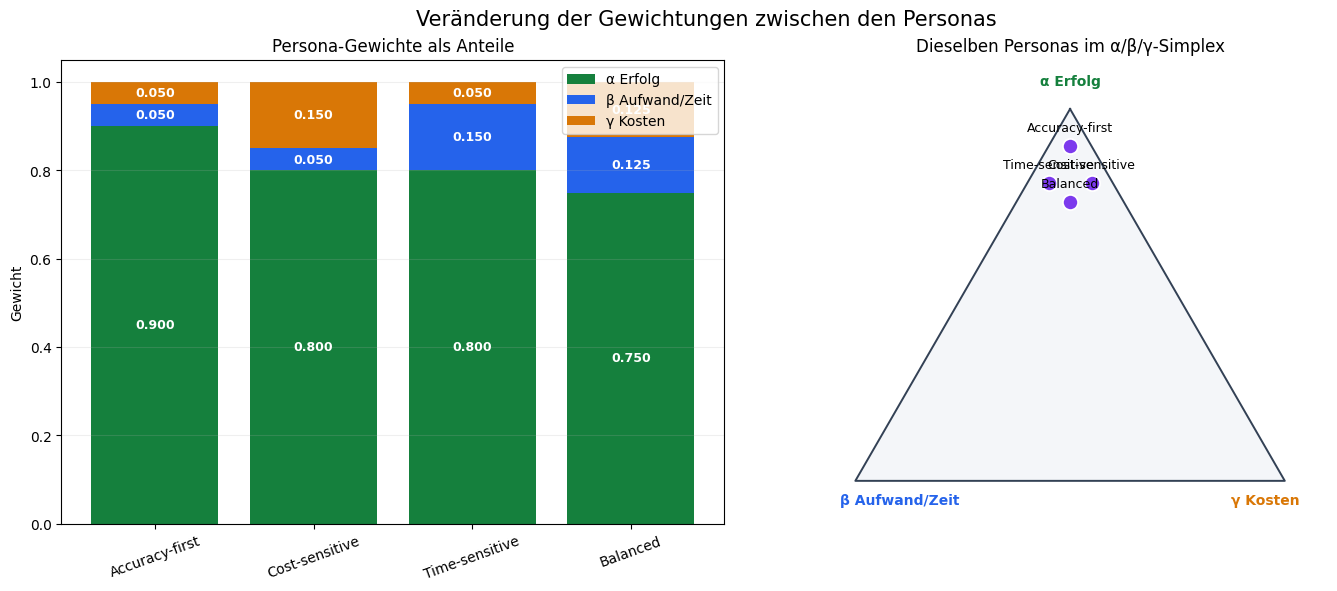

,Persona,α Erfolg,β Aufwand/Zeit,γ Kosten
0,Accuracy-first,0.900,0.050,0.050
1,Cost-sensitive,0.800,0.050,0.150
2,Time-sensitive,0.800,0.150,0.050
3,Balanced,0.750,0.125,0.125


In [95]:
if "logistic_personas" not in globals():
    raise RuntimeError("Bitte zuerst Abschnitt 11 ausfuehren; logistic_personas wurde noch nicht erzeugt.")

persona_weight_plot = pd.DataFrame.from_dict(logistic_personas, orient="index").rename_axis("Persona").reset_index()
persona_weight_plot = persona_weight_plot.rename(columns={
    "alpha": "α Erfolg",
    "beta": "β Aufwand/Zeit",
    "gamma": "γ Kosten",
})

colors = {"α Erfolg": "#15803d", "β Aufwand/Zeit": "#2563eb", "γ Kosten": "#d97706"}
weight_columns = ["α Erfolg", "β Aufwand/Zeit", "γ Kosten"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8), constrained_layout=True)

# Exakte Gewichte als gestapelte Balken.
bottom = np.zeros(len(persona_weight_plot))
for column in weight_columns:
    values = persona_weight_plot[column].to_numpy(dtype=float)
    axes[0].bar(persona_weight_plot["Persona"], values, bottom=bottom, color=colors[column], label=column)
    for idx, (base, value) in enumerate(zip(bottom, values)):
        axes[0].text(idx, base + value / 2, f"{value:.3f}", ha="center", va="center", color="white", fontsize=9, fontweight="bold")
    bottom += values
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Gewicht")
axes[0].set_title("Persona-Gewichte als Anteile")
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend(loc="upper right")
axes[0].grid(axis="y", alpha=0.2)

# Gleiche Gewichte im Simplex: beta unten links, gamma unten rechts, alpha oben.
alpha_corner = np.array([0.5, np.sqrt(3) / 2])
beta_corner = np.array([0.0, 0.0])
gamma_corner = np.array([1.0, 0.0])
triangle = np.vstack([alpha_corner, beta_corner, gamma_corner, alpha_corner])
axes[1].plot(triangle[:, 0], triangle[:, 1], color="#334155", linewidth=1.4)
axes[1].fill(triangle[:, 0], triangle[:, 1], color="#e2e8f0", alpha=0.35)

for _, row in persona_weight_plot.iterrows():
    x = row["γ Kosten"] + 0.5 * row["α Erfolg"]
    y = (np.sqrt(3) / 2) * row["α Erfolg"]
    axes[1].scatter(x, y, s=120, color="#7c3aed", edgecolor="white", linewidth=1.3, zorder=3)
    axes[1].text(x, y + 0.028, row["Persona"], ha="center", va="bottom", fontsize=9)

axes[1].text(alpha_corner[0], alpha_corner[1] + 0.055, "α Erfolg", ha="center", fontweight="bold", color=colors["α Erfolg"])
axes[1].text(beta_corner[0] - 0.035, beta_corner[1] - 0.055, "β Aufwand/Zeit", ha="left", fontweight="bold", color=colors["β Aufwand/Zeit"])
axes[1].text(gamma_corner[0] + 0.035, gamma_corner[1] - 0.055, "γ Kosten", ha="right", fontweight="bold", color=colors["γ Kosten"])
axes[1].set_xlim(-0.10, 1.10)
axes[1].set_ylim(-0.10, 0.98)
axes[1].set_aspect("equal")
axes[1].axis("off")
axes[1].set_title("Dieselben Personas im α/β/γ-Simplex")

fig.suptitle("Veränderung der Gewichtungen zwischen den Personas", fontsize=15)
plt.show()

display(persona_weight_plot.style.format({column: "{:.3f}" for column in weight_columns}))


## 13. Utility-Landschaften bei Veränderung von α, β und γ

Diese Darstellung zeigt nicht nur die Persona-Gewichte, sondern ihre Wirkung auf die Utility.

Für jeden Punkt gilt:

$$
\alpha+\beta+\gamma=1,\qquad \alpha\geq0.75,\qquad \beta+\gamma\leq0.25
$$

Die Karten verwenden auf der x-Achse $\gamma$ für Kosten und auf der y-Achse $\beta$ für Aufwand/Zeit. Daraus folgt $\alpha=1-\beta-\gamma$. Die Farbe zeigt die jeweils höchste erreichbare Utility über **alle** H/k-Kombinationen; die Detailkarten zeigen zusätzlich, wie sich die Utility von `h5/k5` selbst verändert.


### 13.1 Welche H/k-Kombination gewinnt bei welchen Gewichtungen?

,Sigmoid-Steilheit,Modell,H/k,Gewinnerpunkte,Gewinneranteil,mittlere Gewinnerutility
0,5,additiv,h0/k5,215,61.3%,0.54918
1,5,additiv,h5/k5,136,38.7%,0.55850
2,5,multiplikativ,h0/k5,246,70.1%,0.54910
3,5,multiplikativ,h5/k5,105,29.9%,0.55809
4,10,additiv,h0/k5,215,61.3%,0.59741
5,10,additiv,h5/k5,136,38.7%,0.61473
6,10,multiplikativ,h0/k5,275,78.3%,0.59711
7,10,multiplikativ,h5/k5,76,21.7%,0.61441
8,20,additiv,h0/k5,231,65.8%,0.68746
9,20,additiv,h5/k5,120,34.2%,0.71706


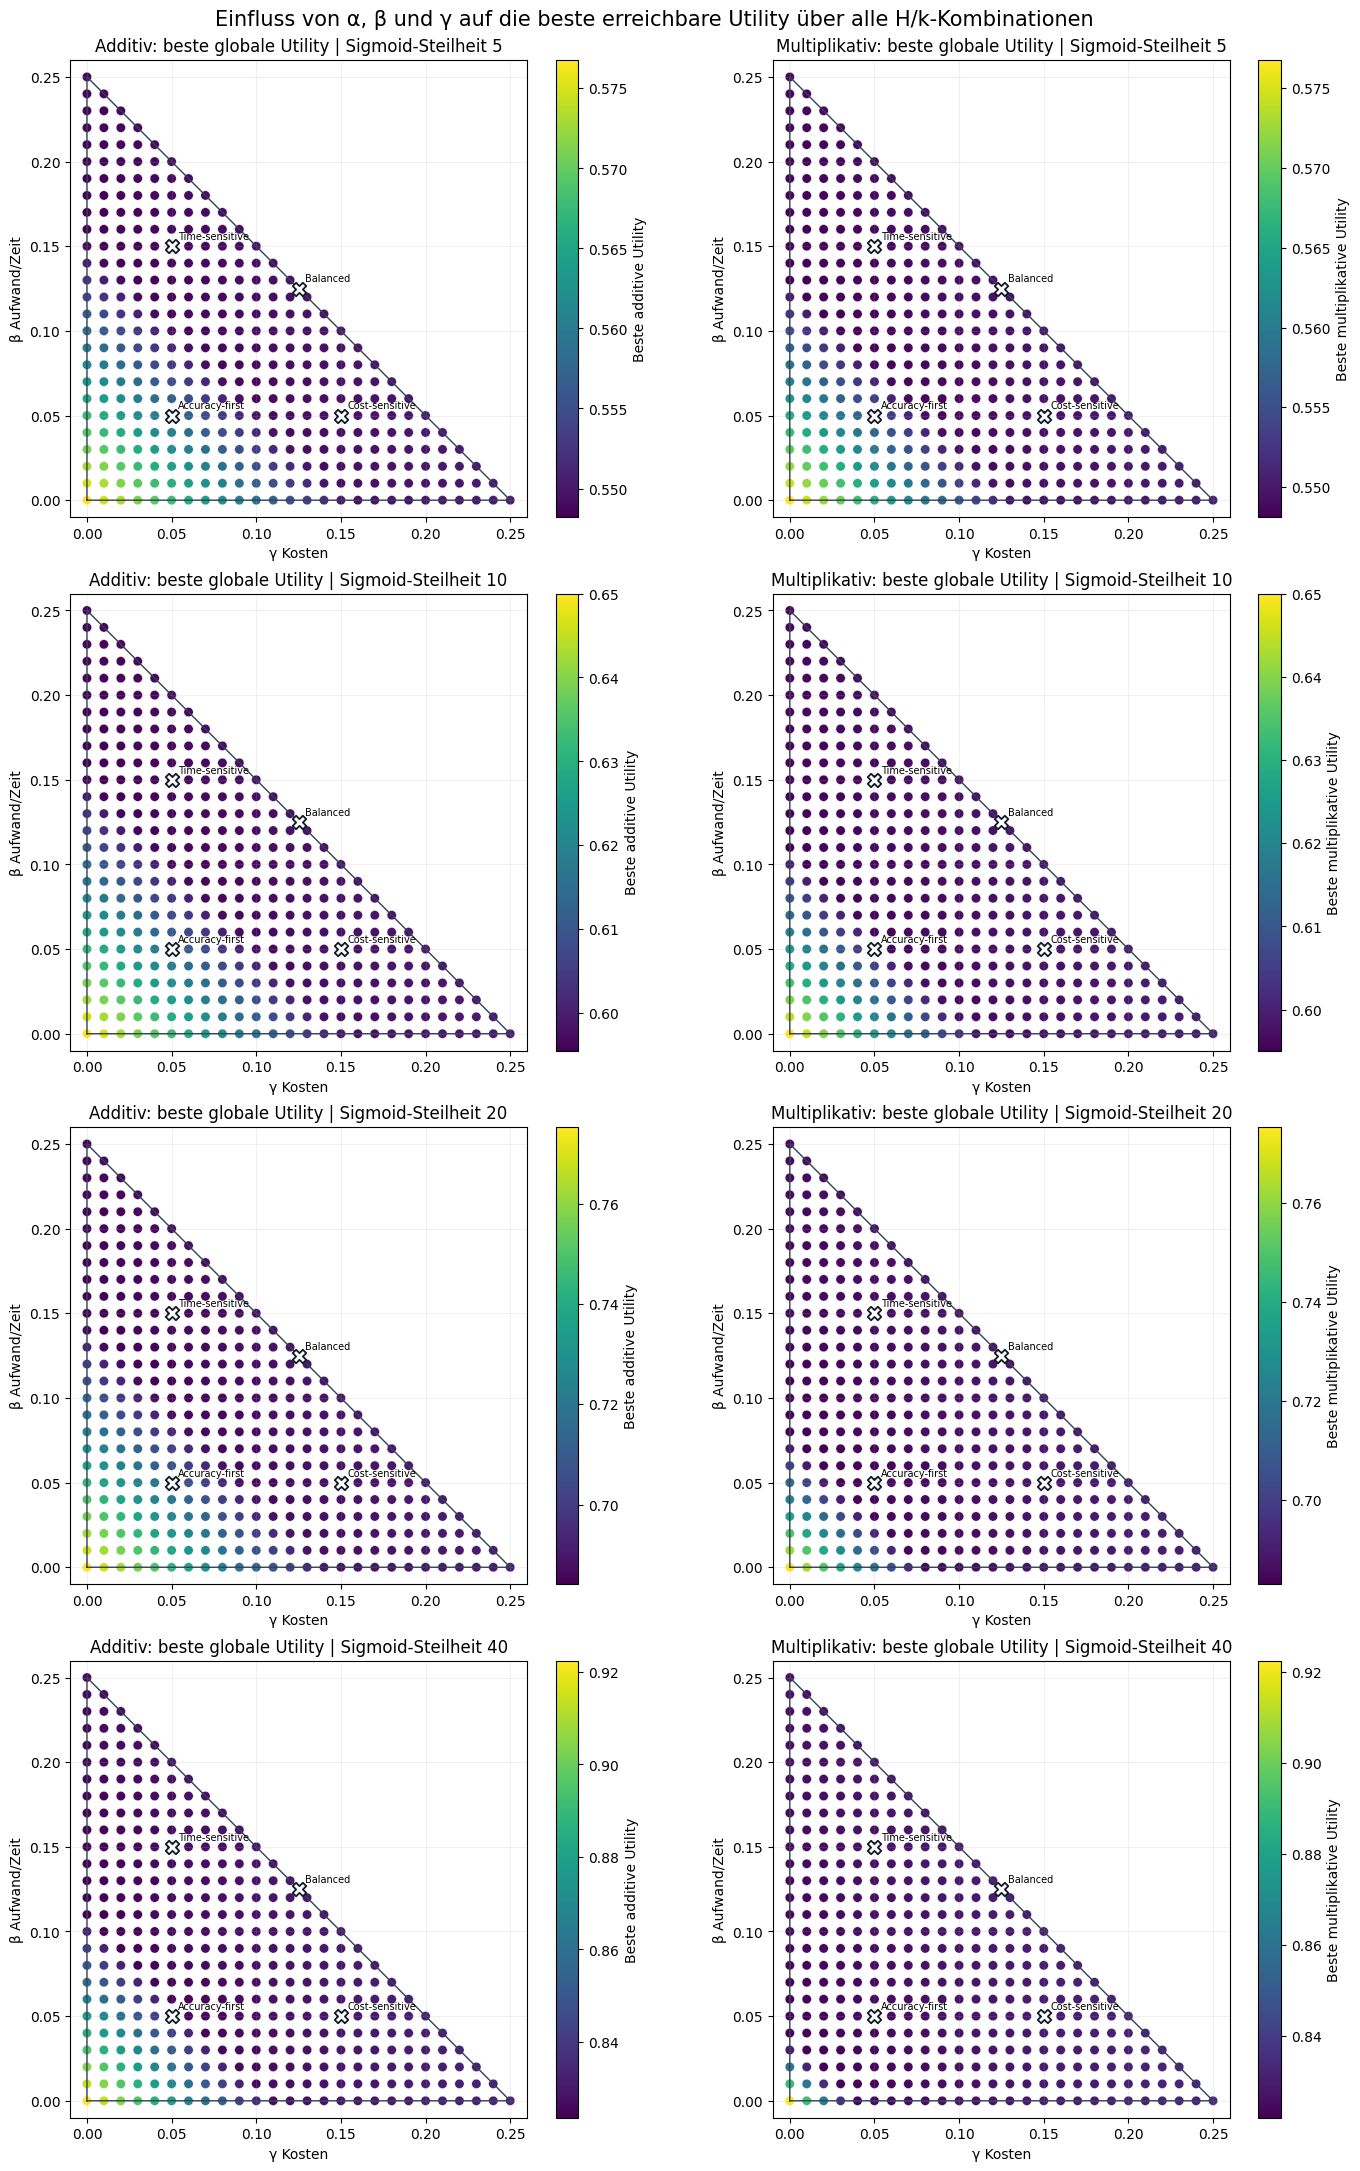

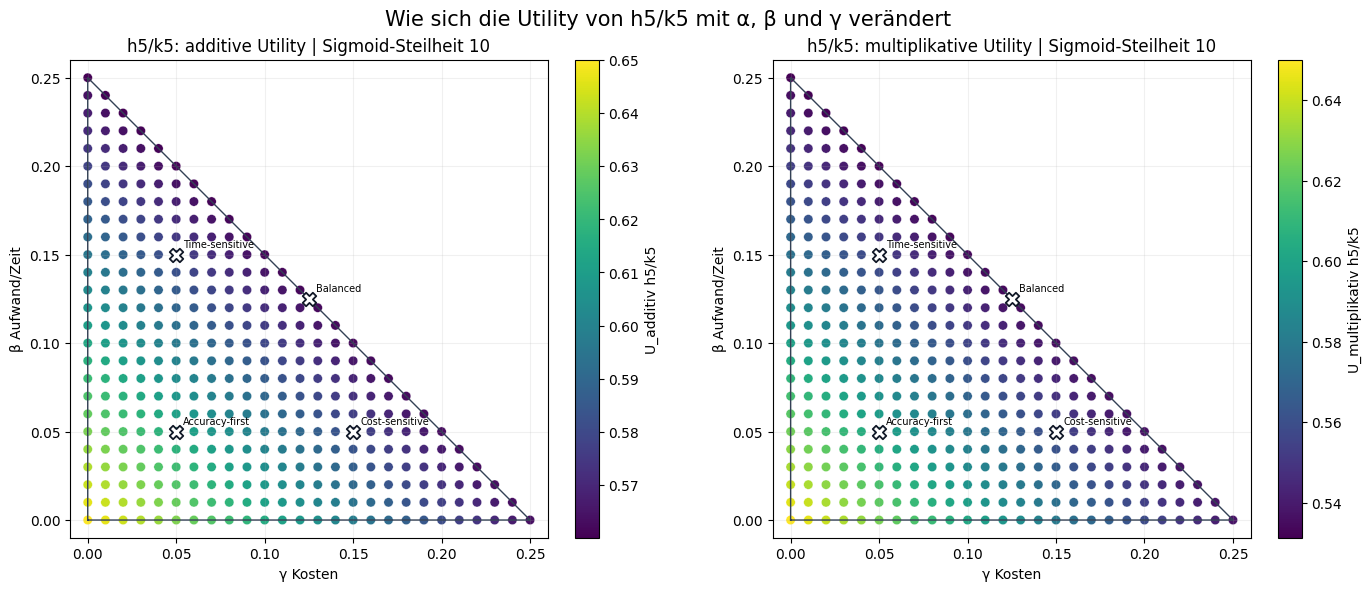

### 13.2 Extrempunkte von h5/k5 im α/β/γ-Raum

,α Erfolg,β Aufwand/Zeit,γ Kosten,U_additiv,U_multiplikativ
Maximum additiv,1.000,0.000,0.000,0.65000,nan
Minimum additiv,0.750,0.250,0.000,0.56005,nan
Maximum multiplikativ,1.000,0.000,0.000,nan,0.65000
Minimum multiplikativ,0.750,0.250,0.000,nan,0.53133


In [97]:
if "persona_hk_df" not in globals() or "sigmoid_slopes" not in globals():
    raise RuntimeError("Bitte zuerst die Abschnitte 10 und 11 ausfuehren.")

UTILITY_WEIGHT_STEP = 0.01
H5K5_LANDSCAPE_SLOPE = 10  # Kann auf 5, 10, 20 oder 40 gesetzt werden.


def make_persona_weight_space(step=UTILITY_WEIGHT_STEP):
    rows = []
    values = np.round(np.arange(0.0, 0.25 + step / 2, step), 6)
    for beta_aufwand in values:
        for gamma_kosten in values:
            alpha_erfolg = round(1.0 - beta_aufwand - gamma_kosten, 6)
            if alpha_erfolg < 0.75 - 1e-9:
                continue
            rows.append({
                "α Erfolg": alpha_erfolg,
                "β Aufwand/Zeit": beta_aufwand,
                "γ Kosten": gamma_kosten,
            })
    return pd.DataFrame(rows)


def compute_weight_utility_landscape(hk_table, sigmoid_slope, weight_space):
    candidates = hk_table.copy()
    candidates["U_Erfolg"] = logistic_success(candidates["success_rate"], sigmoid_slope, S0)
    candidates["U_Kosten"] = logistic_decreasing(candidates["kosten_norm"], sigmoid_slope, K0)
    candidates["U_Aufwand"] = logistic_decreasing(candidates["aufwand_norm"], sigmoid_slope, A0)

    combined = weight_space.assign(_join=1).merge(candidates.assign(_join=1), on="_join").drop(columns="_join")
    combined["U_additiv"] = (
        combined["α Erfolg"] * combined["U_Erfolg"]
        + combined["β Aufwand/Zeit"] * combined["U_Aufwand"]
        + combined["γ Kosten"] * combined["U_Kosten"]
    )
    combined["U_multiplikativ"] = (
        combined["U_Erfolg"] ** combined["α Erfolg"]
        * combined["U_Aufwand"] ** combined["β Aufwand/Zeit"]
        * combined["U_Kosten"] ** combined["γ Kosten"]
    )
    return combined


def select_landscape_winners(landscape, utility_column):
    return (
        landscape.sort_values(
            ["α Erfolg", "β Aufwand/Zeit", "γ Kosten", utility_column, "success_rate", "kosten_raw", "aufwand_s_raw"],
            ascending=[True, True, True, False, False, True, True],
        )
        .groupby(["α Erfolg", "β Aufwand/Zeit", "γ Kosten"], as_index=False)
        .head(1)
        .reset_index(drop=True)
    )


def draw_weight_space(ax, frame, utility_column, title, show_personas=True):
    scatter = ax.scatter(
        frame["γ Kosten"], frame["β Aufwand/Zeit"], c=frame[utility_column],
        cmap="viridis", s=45, edgecolor="white", linewidth=0.25,
    )
    # Zulässiges Dreieck: alpha >= 0.75, beta >= 0, gamma >= 0.
    boundary_x = [0, 0.25, 0, 0]
    boundary_y = [0, 0, 0.25, 0]
    ax.plot(boundary_x, boundary_y, color="#334155", linewidth=1.0)
    if show_personas:
        for persona_name, weights in logistic_personas.items():
            ax.scatter(weights["gamma"], weights["beta"], marker="X", s=95, color="white", edgecolor="#111827", linewidth=1.3, zorder=4)
            ax.text(weights["gamma"] + 0.004, weights["beta"] + 0.004, persona_name, fontsize=7, zorder=5)
    ax.set_title(title)
    ax.set_xlabel("γ Kosten")
    ax.set_ylabel("β Aufwand/Zeit")
    ax.set_xlim(-0.01, 0.26)
    ax.set_ylim(-0.01, 0.26)
    ax.set_aspect("equal")
    ax.grid(alpha=0.18)
    return scatter


weight_space_grid = make_persona_weight_space()
landscapes = {slope: compute_weight_utility_landscape(persona_hk_df, slope, weight_space_grid) for slope in sigmoid_slopes}
landscape_winners = {}
landscape_summary_rows = []
for slope, landscape in landscapes.items():
    for model, utility_column in [("additiv", "U_additiv"), ("multiplikativ", "U_multiplikativ")]:
        winners = select_landscape_winners(landscape, utility_column)
        landscape_winners[(slope, model)] = winners
        winner_counts = winners["hk"].value_counts()
        for hk, count in winner_counts.items():
            landscape_summary_rows.append({
                "Sigmoid-Steilheit": slope,
                "Modell": model,
                "H/k": hk,
                "Gewinnerpunkte": count,
                "Gewinneranteil": count / len(winners) * 100,
                "mittlere Gewinnerutility": winners.loc[winners["hk"].eq(hk), utility_column].mean(),
            })

landscape_summary = pd.DataFrame(landscape_summary_rows).sort_values(
    ["Sigmoid-Steilheit", "Modell", "Gewinneranteil"], ascending=[True, True, False]
)
display(Markdown("### 13.1 Welche H/k-Kombination gewinnt bei welchen Gewichtungen?"))
display(landscape_summary.style.format({
    "Sigmoid-Steilheit": "{:.0f}", "Gewinnerpunkte": "{:.0f}", "Gewinneranteil": "{:.1f}%", "mittlere Gewinnerutility": "{:.5f}",
}).background_gradient(subset=["Gewinneranteil", "mittlere Gewinnerutility"], cmap="YlGn"))

# Globale Utility-Landschaften: pro Zeile eine Sigmoid-Steilheit, pro Spalte eine Verknuepfung.
fig, axes = plt.subplots(len(sigmoid_slopes), 2, figsize=(14, 5.4 * len(sigmoid_slopes)), constrained_layout=True)
for row, slope in enumerate(sigmoid_slopes):
    additive_winners = landscape_winners[(slope, "additiv")]
    multiplicative_winners = landscape_winners[(slope, "multiplikativ")]
    sc_add = draw_weight_space(
        axes[row, 0], additive_winners, "U_additiv",
        f"Additiv: beste globale Utility | Sigmoid-Steilheit {slope}",
    )
    sc_mul = draw_weight_space(
        axes[row, 1], multiplicative_winners, "U_multiplikativ",
        f"Multiplikativ: beste globale Utility | Sigmoid-Steilheit {slope}",
    )
    fig.colorbar(sc_add, ax=axes[row, 0], label="Beste additive Utility")
    fig.colorbar(sc_mul, ax=axes[row, 1], label="Beste multiplikative Utility")
fig.suptitle("Einfluss von α, β und γ auf die beste erreichbare Utility über alle H/k-Kombinationen", fontsize=15)
plt.show()

# Detailkarten fuer h5/k5: dieselben Gewichte, aber ohne Wechsel zu anderen H/k-Kandidaten.
h5k5_landscape = landscapes[H5K5_LANDSCAPE_SLOPE]
h5k5_landscape = h5k5_landscape[h5k5_landscape["hk"].eq("h5/k5")].copy()
if h5k5_landscape.empty:
    display(Markdown("`h5/k5` ist in der aggregierten Tabelle nicht vorhanden; Detailkarten werden uebersprungen."))
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.8), constrained_layout=True)
    sc_add = draw_weight_space(
        axes[0], h5k5_landscape, "U_additiv",
        f"h5/k5: additive Utility | Sigmoid-Steilheit {H5K5_LANDSCAPE_SLOPE}",
    )
    sc_mul = draw_weight_space(
        axes[1], h5k5_landscape, "U_multiplikativ",
        f"h5/k5: multiplikative Utility | Sigmoid-Steilheit {H5K5_LANDSCAPE_SLOPE}",
    )
    fig.colorbar(sc_add, ax=axes[0], label="U_additiv h5/k5")
    fig.colorbar(sc_mul, ax=axes[1], label="U_multiplikativ h5/k5")
    fig.suptitle("Wie sich die Utility von h5/k5 mit α, β und γ verändert", fontsize=15)
    plt.show()

    h5k5_weight_extrema = pd.DataFrame([
        h5k5_landscape.loc[h5k5_landscape["U_additiv"].idxmax(), ["α Erfolg", "β Aufwand/Zeit", "γ Kosten", "U_additiv"]],
        h5k5_landscape.loc[h5k5_landscape["U_additiv"].idxmin(), ["α Erfolg", "β Aufwand/Zeit", "γ Kosten", "U_additiv"]],
        h5k5_landscape.loc[h5k5_landscape["U_multiplikativ"].idxmax(), ["α Erfolg", "β Aufwand/Zeit", "γ Kosten", "U_multiplikativ"]],
        h5k5_landscape.loc[h5k5_landscape["U_multiplikativ"].idxmin(), ["α Erfolg", "β Aufwand/Zeit", "γ Kosten", "U_multiplikativ"]],
    ], index=["Maximum additiv", "Minimum additiv", "Maximum multiplikativ", "Minimum multiplikativ"])
    display(Markdown("### 13.2 Extrempunkte von h5/k5 im α/β/γ-Raum"))
    display(h5k5_weight_extrema.style.format({
        "α Erfolg": "{:.3f}", "β Aufwand/Zeit": "{:.3f}", "γ Kosten": "{:.3f}",
        "U_additiv": "{:.5f}", "U_multiplikativ": "{:.5f}",
    }))
